# 의원 활동 추적 LangGraph 워크플로우

특정 국회의원 이름을 입력하면 열린국회정보 API를 호출해서 아래 정보를 조회합니다.

- 의원이 발의한 법안: 대표발의 / 공동발의 분리
- 의원의 본회의 표결 기록: 최근 찬성 / 반대 법안
- 의원의 본회의 불참 기록: 불참한 본회의 표결

1차 구현은 API 응답 기반의 구조화와 요약에 집중합니다. 이후 단계에서 법안 주제 분류, 의원 간 비교, LLM 기반 해석 노드를 추가할 수 있습니다.

In [1]:
from __future__ import annotations

import json
import hashlib
import html
import os
import re
import sys
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, TypedDict
from urllib.parse import quote_plus

import requests
from dotenv import load_dotenv
from IPython.display import Markdown, display
from langgraph.graph import END, START, StateGraph

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from langchain_core.messages import HumanMessage, SystemMessage
    from langchain_google_genai import ChatGoogleGenerativeAI
except Exception:
    ChatGoogleGenerativeAI = None
    HumanMessage = None
    SystemMessage = None

CWD = Path.cwd()
NOTEBOOK_DIR = Path("/home/pck/메타코드 부트캠프/LangGraph _국회챗봇/의원챗봇")
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = CWD
PARENT_CANDIDATES = [CWD, CWD.parent, NOTEBOOK_DIR, NOTEBOOK_DIR.parent]
for candidate in PARENT_CANDIDATES:
    if (candidate / "utils.py").exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))

try:
    from utils import visualize_graph
except Exception:
    visualize_graph = None

for env_path in [CWD / ".env", CWD.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path)

WORKFLOW_VERSION = "member_activity_v11_readable_output"
BASE_URL = "https://open.assembly.go.kr/portal/openapi"
ENDPOINT_MEMBER_BILLS = "nzmimeepazxkubdpn"  # 국회의원 발의법률안
ENDPOINT_MEMBER_VOTES = "nojepdqqaweusdfbi"  # 국회의원 본회의 표결정보
ENDPOINT_VOTE_BILLS = "ncocpgfiaoituanbr"  # 의안별 표결현황
ENDPOINT_MEMBERS = "ALLNAMEMBER"  # 국회의원 정보 통합 API
HTTP_TIMEOUT = 20
NEWS_HTTP_TIMEOUT = 8
SUPPORTED_MEMBER_TERMS = list(range(1, 23))
SUPPORTED_BILL_TERMS = list(range(10, 23))
SUPPORTED_VOTE_TERMS = [20, 21, 22]
DEFAULT_TERMS = list(range(22, 0, -1))
DEFAULT_RECENT_LIMIT = 10
DEFAULT_MAX_BILL_PAGES = 2
DEFAULT_MAX_VOTE_PAGES = 200
DEFAULT_MAX_VOTE_BILLS_TO_SCAN = 0  # 0이면 해당 대수의 표결 의안 전체 조회
DEFAULT_VOTE_FETCH_WORKERS = 8
DEFAULT_PARTY_ALIGNMENT_LIMIT = 50
DEFAULT_LLM_INSIGHTS_ENABLED = True
DEFAULT_LLM_MODEL = "gemini-2.5-flash-lite"
DEFAULT_RECENT_NEWS_LIMIT = 10
RECENT_NEWS_CACHE_TTL_HOURS = 6
DEFAULT_ENABLE_COSPONSOR_SCAN = True
DEFAULT_MAX_COSPONSOR_SCAN_PAGES = 5
DEFAULT_SHOW_PROGRESS = True
CACHE_TTL_HOURS = 24
CACHE_DIR = NOTEBOOK_DIR / "cache" / "member_activity"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


class MemberActivityState(TypedDict, total=False):
    member_name: str
    assembly_terms: List[int]
    member_terms: List[int]
    bill_terms: List[int]
    vote_terms: List[int]
    all_vote_terms: List[int]
    additional_vote_terms: List[int]
    unsupported_member_terms: List[int]
    unsupported_bill_terms: List[int]
    unsupported_vote_terms: List[int]
    served_terms: List[int]
    analysis_terms: List[int]
    non_served_terms: List[int]
    recent_limit: int
    max_bill_pages: int
    max_vote_pages: int
    max_vote_bills_to_scan: int
    vote_fetch_workers: int
    party_alignment_enabled: bool
    party_alignment_vote_limit: int
    llm_insights_enabled: bool
    max_cosponsor_scan_pages: int
    enable_cosponsor_scan: bool
    show_progress: bool
    member_info: List[Dict[str, Any]]
    sponsored_bills: List[Dict[str, Any]]
    representative_bills: List[Dict[str, Any]]
    cosponsored_bills: List[Dict[str, Any]]
    bill_result_stats: List[Dict[str, Any]]
    bill_committee_stats: List[Dict[str, Any]]
    legislative_interest_context: Dict[str, Any]
    legislative_interest_analysis: str
    legislative_interest_analysis_source: str
    recent_news_query: str
    recent_news_items: List[Dict[str, Any]]
    recent_news_analysis: str
    recent_news_analysis_source: str
    vote_records: List[Dict[str, Any]]
    yes_votes: List[Dict[str, Any]]
    no_votes: List[Dict[str, Any]]
    abstain_votes: List[Dict[str, Any]]
    absent_votes: List[Dict[str, Any]]
    vote_summary_by_term: List[Dict[str, Any]]
    vote_fetch_stats: List[Dict[str, Any]]
    party_alignment_summary: List[Dict[str, Any]]
    party_alignment_records: List[Dict[str, Any]]
    party_alignment_dissent_votes: List[Dict[str, Any]]
    party_alignment_excluded_votes: List[Dict[str, Any]]
    party_alignment_fetch_stats: List[Dict[str, Any]]
    vote_interpretation_context: Dict[str, Any]
    vote_interpretation_analysis: str
    vote_interpretation_analysis_source: str
    profile_summary: str
    summary: str
    errors: List[str]


def env_value(name: str) -> Optional[str]:
    value = os.getenv(name)
    if value:
        return value.strip().strip("'\"")
    for key, val in os.environ.items():
        if key.strip() == name and val:
            return val.strip().strip("'\"")
    return None


def get_assembly_api_key() -> str:
    api_key = env_value("OPENCONGRESS_KEY") or env_value("OPENCONGRESS_key") or env_value("ASSEMBLY_API_KEY")
    if not api_key:
        api_key = input("열린국회정보 API KEY를 입력하세요: ").strip()
    if not api_key:
        raise ValueError("열린국회정보 API KEY가 필요합니다. .env에 OPENCONGRESS_key를 설정하세요.")
    return api_key


def get_google_api_key() -> Optional[str]:
    api_key = env_value("GOOGLE_API_KEY") or env_value("GEMINI_API_KEY")
    if api_key and not os.getenv("GOOGLE_API_KEY"):
        os.environ["GOOGLE_API_KEY"] = api_key
    return api_key


def sanitize_error(error: Exception | str) -> str:
    text = str(error)
    for key_name in ["OPENCONGRESS_KEY", "OPENCONGRESS_key", "ASSEMBLY_API_KEY"]:
        key = env_value(key_name)
        if key:
            text = text.replace(key, "***")
    text = re.sub(r"([?&]KEY=)[^&\s]+", r"\1***", text)
    return text


def normalize_space(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip()


def normalize_markdown(value: Any) -> str:
    text = str(value or "").replace("\r\n", "\n").replace("\r", "\n")
    lines = [re.sub(r"[ \t]+", " ", line).strip() for line in text.split("\n")]
    collapsed: List[str] = []
    previous_blank = False
    for line in lines:
        is_blank = not line
        if is_blank and previous_blank:
            continue
        collapsed.append(line)
        previous_blank = is_blank
    return "\n".join(collapsed).strip()


def strip_html(value: Any) -> str:
    text = html.unescape(str(value or ""))
    text = re.sub(r"<[^>]+>", " ", text)
    return normalize_space(text)


def first_present(record: Dict[str, Any], keys: Iterable[str]) -> str:
    for key in keys:
        value = normalize_space(record.get(key))
        if value:
            return value
    return ""


def member_name_from_row(record: Dict[str, Any]) -> str:
    return first_present(record, ["HG_NM", "NAAS_NM", "MEMBER_NM", "MNA_NM", "NAME", "VOTER_NM"])


def member_code_from_row(record: Dict[str, Any]) -> str:
    return first_present(record, ["MONA_CD", "NAAS_CD", "NASS_CD", "MEMBER_NO"])


def party_name_from_row(record: Dict[str, Any]) -> str:
    return first_present(record, ["POLY_NM", "PLPT_NM", "PARTY_NM", "POLY_NM_REAL"])


def district_name_from_row(record: Dict[str, Any]) -> str:
    return first_present(record, ["ORIG_NM", "ELECD_NM", "DISTRICT_NM"])


def contains_name(value: Any, member_name: str) -> bool:
    return normalize_space(member_name) in normalize_space(value)


def member_name_variants(member_name: str) -> List[str]:
    name = normalize_space(member_name).replace("의원", "")
    variants = [name, f"{name}의원"]
    return [variant for index, variant in enumerate(variants) if variant and variant not in variants[:index]]


def normalize_terms(value: Any) -> List[int]:
    if value is None:
        return DEFAULT_TERMS[:]
    if isinstance(value, int):
        raw_terms = [value]
    elif isinstance(value, str):
        raw_terms = [int(part) for part in re.findall(r"\d+", value)]
    else:
        raw_terms = [int(term) for term in value]
    terms: List[int] = []
    for term in raw_terms:
        if 1 <= term <= 22 and term not in terms:
            terms.append(term)
    return terms or DEFAULT_TERMS[:]


def intersect_terms(requested_terms: List[int], supported_terms: List[int]) -> List[int]:
    supported = set(supported_terms)
    return [term for term in requested_terms if term in supported]


def unsupported_terms(requested_terms: List[int], supported_terms: List[int]) -> List[int]:
    supported = set(supported_terms)
    return [term for term in requested_terms if term not in supported]


def format_terms(terms: Iterable[int]) -> str:
    values = list(terms)
    return ", ".join(f"{term}대" for term in values) if values else "없음"


def parse_term_selection(value: str, allowed_terms: List[int]) -> List[int]:
    allowed = set(int(term) for term in allowed_terms)
    selected: List[int] = []
    for number in re.findall(r"\d+", normalize_space(value)):
        term = int(number)
        if term in allowed and term not in selected:
            selected.append(term)
    return selected


def extract_terms_from_text(value: Any) -> List[int]:
    text = normalize_space(value)
    if not text:
        return []
    terms: List[int] = []
    for number in re.findall(r"\d+", text):
        term = int(number)
        if 1 <= term <= 22 and term not in terms:
            terms.append(term)
    return terms


def extract_served_terms(member_records: List[Dict[str, Any]]) -> List[int]:
    terms: List[int] = []
    # 재임 대수는 GTELT_ERACO 같은 구조화 필드만 사용합니다.
    # BRF_HST 약력은 연도/선거명/경력 숫자가 섞여 있어 재임 대수 추출에 쓰면 오분류가 납니다.
    for record in member_records:
        for key in ["GTELT_ERACO", "ERACO", "_REQUEST_AGE"]:
            for term in extract_terms_from_text(record.get(key)):
                if term not in terms:
                    terms.append(term)
    return sorted(terms, reverse=True)


def progress_log(state: MemberActivityState, message: str) -> None:
    if state.get("show_progress", DEFAULT_SHOW_PROGRESS):
        print(f"[진행] {message}", flush=True)


def cache_path(namespace: str, key_parts: Iterable[Any]) -> Path:
    key = json.dumps([str(part) for part in key_parts], ensure_ascii=False, sort_keys=True)
    digest = hashlib.sha1(key.encode("utf-8")).hexdigest()
    folder = CACHE_DIR / namespace
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"{digest}.json"


def is_cache_fresh(namespace: str, key_parts: Iterable[Any], ttl_hours: int = CACHE_TTL_HOURS) -> bool:
    path = cache_path(namespace, key_parts)
    if not path.exists():
        return False
    try:
        age_seconds = datetime.now().timestamp() - path.stat().st_mtime
        return ttl_hours <= 0 or age_seconds <= ttl_hours * 3600
    except Exception:
        return False


def load_cache(namespace: str, key_parts: Iterable[Any], ttl_hours: int = CACHE_TTL_HOURS) -> Optional[Any]:
    path = cache_path(namespace, key_parts)
    if not path.exists():
        return None
    try:
        age_seconds = datetime.now().timestamp() - path.stat().st_mtime
        if ttl_hours > 0 and age_seconds > ttl_hours * 3600:
            return None
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None


def save_cache(namespace: str, key_parts: Iterable[Any], value: Any) -> None:
    path = cache_path(namespace, key_parts)
    path.write_text(json.dumps(value, ensure_ascii=False), encoding="utf-8")


def parse_openapi_rows(data: Any, api_res: str) -> List[Dict[str, Any]]:
    if not isinstance(data, dict):
        return []
    candidates: List[Any] = []
    if api_res in data:
        candidates.append(data[api_res])
    candidates.extend(data.values())
    for candidate in candidates:
        if isinstance(candidate, list):
            for item in candidate:
                if isinstance(item, dict) and isinstance(item.get("row"), list):
                    return item["row"]
        if isinstance(candidate, dict) and isinstance(candidate.get("row"), list):
            return candidate["row"]
    return []


@dataclass
class AssemblyAPIClient:
    api_key: str

    def get_rows(self, api_res: str, params: Dict[str, Any], max_pages: int = 1) -> List[Dict[str, Any]]:
        rows: List[Dict[str, Any]] = []
        for page in range(1, max_pages + 1):
            p_size = int(params.get("pSize", 100))
            query_params = {key: value for key, value in params.items() if key != "pSize" and value not in (None, "")}
            payload = {"KEY": self.api_key, "Type": "json", "pIndex": page, "pSize": p_size, **query_params}
            response = requests.get(f"{BASE_URL}/{api_res}", params=payload, timeout=HTTP_TIMEOUT)
            response.raise_for_status()
            data = response.json()
            result = data.get("RESULT") if isinstance(data, dict) else None
            if isinstance(result, dict) and normalize_space(result.get("CODE")).startswith("ERROR"):
                raise RuntimeError(normalize_space(result.get("MESSAGE")) or normalize_space(result.get("CODE")))
            page_rows = parse_openapi_rows(data, api_res)
            if not page_rows:
                break
            rows.extend(page_rows)
            if len(page_rows) < p_size:
                break
        return rows


def dedupe_records(records: Iterable[Dict[str, Any]], key_candidates: List[str]) -> List[Dict[str, Any]]:
    seen = set()
    result: List[Dict[str, Any]] = []
    for record in records:
        key_parts = [normalize_space(record.get(key)) for key in key_candidates if normalize_space(record.get(key))]
        key = "|".join(key_parts) if key_parts else json.dumps(record, ensure_ascii=False, sort_keys=True)
        if key in seen:
            continue
        seen.add(key)
        result.append(record)
    return result


def parse_date(value: Any) -> Optional[datetime]:
    text = normalize_space(value)
    if not text:
        return None
    text = text.replace("/", "-").replace(".", "-")
    candidates = [text[:10], text[:8], text[:9], text[:11], text]
    for fmt in ("%Y-%m-%d", "%Y%m%d", "%d-%b-%y", "%d-%b-%Y"):
        for candidate in candidates:
            try:
                return datetime.strptime(candidate, fmt)
            except ValueError:
                continue
    return None


def date_sort_value(record: Dict[str, Any], *keys: str) -> datetime:
    for key in keys:
        parsed = parse_date(record.get(key))
        if parsed:
            return parsed
    return datetime.min


def classify_bill_role(record: Dict[str, Any], member_name: str) -> str:
    if contains_name(record.get("RST_PROPOSER"), member_name):
        return "대표발의"
    if contains_name(record.get("PUBL_PROPOSER"), member_name):
        return "공동발의"
    if contains_name(record.get("PROPOSER"), member_name):
        return "발의자"
    return "확인필요"


def normalize_vote_result(record: Dict[str, Any]) -> str:
    raw = first_present(record, ["RESULT_VOTE_MOD", "RESULT_VOTE", "VOTE_RESULT", "VOTE_RESULT_NM", "RESULT", "RESULT_NM"])
    if "찬성" in raw:
        return "찬성"
    if "반대" in raw:
        return "반대"
    if "기권" in raw:
        return "기권"
    if "불참" in raw or "결석" in raw:
        return "불참"
    return raw or "미확인"


def select_columns(records: List[Dict[str, Any]], columns: List[str]) -> List[Dict[str, Any]]:
    return [{column: record.get(column, "") for column in columns} for record in records]


def count_by_field(records: List[Dict[str, Any]], field: str) -> Dict[str, int]:
    counts: Dict[str, int] = {}
    for record in records:
        key = normalize_space(record.get(field)) or "미확인"
        counts[key] = counts.get(key, 0) + 1
    return counts


def format_counts(counts: Dict[str, int]) -> str:
    if not counts:
        return "없음"
    return " / ".join(f"{key} {value}건" for key, value in sorted(counts.items(), key=lambda item: (-item[1], item[0])))


def counts_to_records(counts: Dict[str, int], label_name: str, count_name: str = "건수") -> List[Dict[str, Any]]:
    return [
        {label_name: key, count_name: value}
        for key, value in sorted(counts.items(), key=lambda item: (-item[1], item[0]))
    ]


def bill_result_summary_text(bills: List[Dict[str, Any]]) -> str:
    counts = count_by_field(bills, "PROC_RESULT")
    if not counts:
        return f"발의 법안: 총 {len(bills)}건"
    return f"발의 법안: 총 {len(bills)}건 / {format_counts(counts)}"


COMMITTEE_THEME_HINTS = {
    "과학기술정보방송통신위원회": "과학기술·디지털·방송통신",
    "행정안전위원회": "행정제도·지방자치·안전",
    "정무위원회": "금융·공정거래·국정운영",
    "교육위원회": "교육정책",
    "기후에너지환경노동위원회": "기후·에너지·환경·노동",
    "국방위원회": "국방·안보",
    "국토교통위원회": "국토·교통·주거",
    "농림축산식품해양수산위원회": "농림축산·식품·해양수산",
    "문화체육관광위원회": "문화·체육·관광",
    "법제사법위원회": "사법·법무·입법체계",
    "보건복지위원회": "보건·복지",
    "재정경제기획위원회": "재정·경제정책",
    "기획재정위원회": "재정·세제·경제정책",
    "산업통상자원중소벤처기업위원회": "산업·통상·중소벤처",
    "외교통일위원회": "외교·통일",
}


def compact_bill_record(record: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "법안명": normalize_space(record.get("BILL_NAME")),
        "발의일": normalize_space(record.get("PROPOSE_DT") or record.get("PPSL_DT")),
        "소관위원회": normalize_space(record.get("COMMITTEE")),
        "처리결과": normalize_space(record.get("PROC_RESULT")) or "미확인",
        "역할": normalize_space(record.get("_ROLE")),
    }


def format_percent(numerator: int, denominator: int) -> str:
    if denominator <= 0:
        return "-"
    return f"{(numerator / denominator) * 100:.1f}%"


def ordered_vote_count_text(counts: Dict[str, int]) -> str:
    keys = ["찬성", "반대", "기권", "불참", "미확인"]
    parts = [f"{key} {int(counts.get(key, 0))}" for key in keys if int(counts.get(key, 0)) > 0]
    return " / ".join(parts) if parts else "없음"


def parse_nonnegative_int(value: str, default: int) -> int:
    text = normalize_space(value)
    if not text:
        return default
    match = re.search(r"\d+", text)
    return int(match.group()) if match else default


def split_multi_value(value: Any) -> List[str]:
    text = normalize_space(value)
    if not text:
        return []
    parts = re.split(r"\s*/\s*|\s*,\s*", text)
    seen: List[str] = []
    for part in parts:
        item = normalize_space(part)
        if item and item not in seen:
            seen.append(item)
    return seen


def compact_list_text(items: List[str], limit: int = 5) -> str:
    if not items:
        return "미확인"
    shown = items[:limit]
    extra = len(items) - len(shown)
    text = ", ".join(shown)
    if extra > 0:
        text += f" 외 {extra}개"
    return text


def markdown_escape(value: Any) -> str:
    return normalize_space(value).replace("|", "&#124;")


def member_profile_markdown_table(member_records: List[Dict[str, Any]], limit: int = 5) -> str:
    if not member_records:
        return ""
    lines = ["| 대수 | 정당 | 선거구 | 당선구분 | 주요 위원회 |", "|---|---|---|---|---|"]
    for row in member_records[:limit]:
        term = normalize_space(row.get("AGE") or row.get("GTELT_ERACO") or row.get("_SERVED_TERMS"))
        if term and term.isdigit():
            term = f"{term}대"
        party = markdown_escape(row.get("PLPT_NM")) or "미확인"
        district = markdown_escape(row.get("ELECD_NM")) or "미확인"
        elected = markdown_escape(row.get("RLCT_DIV_NM") or row.get("ELECD_DIV_NM")) or "미확인"
        committees = split_multi_value(row.get("BLNG_CMIT_NM") or row.get("CMIT_NM"))
        committee_text = markdown_escape(compact_list_text(committees, limit=3))
        lines.append(f"| {markdown_escape(term)} | {party} | {district} | {elected} | {committee_text} |")
    if len(member_records) > limit:
        lines.append(f"| 외 {len(member_records) - limit}건 |  |  |  |  |")
    return "\n".join(lines)


def build_profile_summary(member_name: str, member_records: List[Dict[str, Any]], served_terms: List[int]) -> str:
    if not member_records:
        return f"{member_name} (의원 기본정보 없음)"
    parties: List[str] = []
    districts: List[str] = []
    committees: List[str] = []
    for record in member_records:
        for item in split_multi_value(record.get("PLPT_NM")):
            if item not in parties:
                parties.append(item)
        for item in split_multi_value(record.get("ELECD_NM")):
            if item not in districts:
                districts.append(item)
        for item in split_multi_value(record.get("BLNG_CMIT_NM") or record.get("CMIT_NM")):
            if item not in committees:
                committees.append(item)
    lines = [
        f"**{member_name}**",
        f"- 정당: {compact_list_text(parties, limit=3)}",
        f"- 선거구: {compact_list_text(districts, limit=3)}",
        f"- 재임 대수: {format_terms(served_terms)}",
        f"- 주요 위원회: {compact_list_text(committees, limit=6)}",
    ]
    table = member_profile_markdown_table(member_records)
    if table:
        lines.extend(["", "#### 의원 기본정보", table])
    return "\n".join(lines)


def display_table(title: str, records: List[Dict[str, Any]], columns: List[str], limit: int = 10) -> None:
    display(Markdown(f"### {title}"))
    sliced = select_columns(records[:limit], columns)
    if not sliced:
        display(Markdown("조회된 데이터가 없습니다."))
        return
    if pd is not None:
        display(pd.DataFrame(sliced))
    else:
        display(Markdown("```json\n" + json.dumps(sliced, ensure_ascii=False, indent=2) + "\n```"))


/home/pck/메타코드 부트캠프/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize_input_node(state: MemberActivityState) -> MemberActivityState:
    member_name = normalize_space(state.get("member_name"))
    if not member_name:
        raise ValueError("분석할 의원 이름이 필요합니다.")
    requested_terms = normalize_terms(state.get("assembly_terms"))
    normalized = {
        "member_name": member_name,
        "assembly_terms": requested_terms,
        "member_terms": intersect_terms(requested_terms, SUPPORTED_MEMBER_TERMS),
        "bill_terms": intersect_terms(requested_terms, SUPPORTED_BILL_TERMS),
        "vote_terms": [],
        "all_vote_terms": [],
        "additional_vote_terms": [],
        "unsupported_member_terms": unsupported_terms(requested_terms, SUPPORTED_MEMBER_TERMS),
        "unsupported_bill_terms": unsupported_terms(requested_terms, SUPPORTED_BILL_TERMS),
        "unsupported_vote_terms": unsupported_terms(requested_terms, SUPPORTED_VOTE_TERMS),
        "served_terms": [],
        "analysis_terms": requested_terms,
        "non_served_terms": [],
        "recent_limit": int(state.get("recent_limit") or DEFAULT_RECENT_LIMIT),
        "max_bill_pages": int(state.get("max_bill_pages") or DEFAULT_MAX_BILL_PAGES),
        "max_vote_pages": int(state.get("max_vote_pages") or DEFAULT_MAX_VOTE_PAGES),
        "max_vote_bills_to_scan": int(state.get("max_vote_bills_to_scan", DEFAULT_MAX_VOTE_BILLS_TO_SCAN)),
        "vote_fetch_workers": int(state.get("vote_fetch_workers") or DEFAULT_VOTE_FETCH_WORKERS),
        "party_alignment_enabled": bool(state.get("party_alignment_enabled", True)),
        "party_alignment_vote_limit": int(state.get("party_alignment_vote_limit", DEFAULT_PARTY_ALIGNMENT_LIMIT)),
        "llm_insights_enabled": bool(state.get("llm_insights_enabled", DEFAULT_LLM_INSIGHTS_ENABLED)),
        "max_cosponsor_scan_pages": int(state.get("max_cosponsor_scan_pages") or DEFAULT_MAX_COSPONSOR_SCAN_PAGES),
        "enable_cosponsor_scan": bool(state.get("enable_cosponsor_scan", DEFAULT_ENABLE_COSPONSOR_SCAN)),
        "show_progress": bool(state.get("show_progress", DEFAULT_SHOW_PROGRESS)),
        "errors": [],
    }
    progress_log(normalized, f"입력 정리 완료: {member_name}, 요청 대수 {format_terms(requested_terms)}")
    return normalized


def make_fetch_member_info_node(client: AssemblyAPIClient):
    def fetch_member_info_node(state: MemberActivityState) -> MemberActivityState:
        errors = list(state.get("errors", []))
        member_name = state["member_name"]
        requested_terms = state.get("assembly_terms", DEFAULT_TERMS)
        progress_log(state, "의원 기본정보 조회 시작")
        try:
            rows = client.get_rows(ENDPOINT_MEMBERS, {"NAAS_NM": member_name, "pSize": 100}, max_pages=1)
            exact_rows = [row for row in rows if normalize_space(row.get("NAAS_NM")) == member_name]
            rows = dedupe_records(exact_rows or rows, ["NAAS_CD", "NAAS_NM", "GTELT_ERACO"])
            served_terms = extract_served_terms(rows)
            if served_terms:
                analysis_terms = [term for term in requested_terms if term in served_terms]
                non_served_terms = [term for term in requested_terms if term not in served_terms]
            else:
                analysis_terms = requested_terms
                non_served_terms = []
                errors.append("의원 기본정보에서 재임 대수(GTELT_ERACO)를 추출하지 못해 요청 대수 전체를 분석 대상으로 사용합니다.")
            for row in rows:
                row["_SERVED_TERMS"] = format_terms(served_terms)
            profile_summary = build_profile_summary(member_name, rows, served_terms or analysis_terms)
            all_vote_terms = intersect_terms(analysis_terms, SUPPORTED_VOTE_TERMS)
            initial_vote_terms = all_vote_terms[:1]
            additional_vote_terms = all_vote_terms[1:]
            update = {
                "member_info": rows,
                "profile_summary": profile_summary,
                "served_terms": served_terms,
                "analysis_terms": analysis_terms,
                "non_served_terms": non_served_terms,
                "member_terms": intersect_terms(analysis_terms, SUPPORTED_MEMBER_TERMS),
                "bill_terms": intersect_terms(analysis_terms, SUPPORTED_BILL_TERMS),
                "all_vote_terms": all_vote_terms,
                "vote_terms": initial_vote_terms,
                "additional_vote_terms": additional_vote_terms,
                "unsupported_member_terms": unsupported_terms(analysis_terms, SUPPORTED_MEMBER_TERMS),
                "unsupported_bill_terms": unsupported_terms(analysis_terms, SUPPORTED_BILL_TERMS),
                "unsupported_vote_terms": unsupported_terms(analysis_terms, SUPPORTED_VOTE_TERMS),
                "errors": errors,
            }
            progress_log(state, f"의원 기본정보 조회 완료: {len(rows)}건, 재임 대수 {format_terms(served_terms or analysis_terms)}")
            return update
        except Exception as error:
            errors.append(f"의원정보 조회 실패: {sanitize_error(error)}")
            progress_log(state, "의원 기본정보 조회 실패")
            return {"member_info": [], "errors": errors}
    return fetch_member_info_node


def make_fetch_bills_node(client: AssemblyAPIClient):
    def fetch_bills_node(state: MemberActivityState) -> MemberActivityState:
        errors = list(state.get("errors", []))
        member_name = state["member_name"]
        max_pages = int(state.get("max_bill_pages") or DEFAULT_MAX_BILL_PAGES)
        max_cosponsor_pages = int(state.get("max_cosponsor_scan_pages") or DEFAULT_MAX_COSPONSOR_SCAN_PAGES)
        enable_cosponsor_scan = bool(state.get("enable_cosponsor_scan", DEFAULT_ENABLE_COSPONSOR_SCAN))
        rows: List[Dict[str, Any]] = []
        bill_terms = state.get("bill_terms", SUPPORTED_BILL_TERMS)
        progress_log(state, f"발의법안 조회 시작: {format_terms(bill_terms)}")

        for age in bill_terms:
            try:
                before = len(rows)
                for proposer in member_name_variants(member_name):
                    page_rows = client.get_rows(ENDPOINT_MEMBER_BILLS, {"AGE": age, "PROPOSER": proposer, "pSize": 100}, max_pages=max_pages)
                    for row in page_rows:
                        row["_REQUEST_AGE"] = age
                        row["_ROLE"] = classify_bill_role(row, member_name)
                    rows.extend(page_rows)
                if enable_cosponsor_scan:
                    progress_log(state, f"{age}대 공동발의 보강 스캔: 최대 {max_cosponsor_pages}페이지")
                    scan_rows = client.get_rows(ENDPOINT_MEMBER_BILLS, {"AGE": age, "pSize": 100}, max_pages=max_cosponsor_pages)
                    for row in scan_rows:
                        if contains_name(row.get("PUBL_PROPOSER"), member_name):
                            row["_REQUEST_AGE"] = age
                            row["_ROLE"] = "공동발의"
                            rows.append(row)
                progress_log(state, f"{age}대 발의법안 조회 완료: {len(rows) - before}건 추가")
            except Exception as error:
                errors.append(f"{age}대 발의법안 조회 실패: {sanitize_error(error)}")
                progress_log(state, f"{age}대 발의법안 조회 실패")

        rows = dedupe_records(rows, ["BILL_ID", "BILL_NO", "BILL_NAME"])
        rows = sorted(rows, key=lambda row: date_sort_value(row, "PROPOSE_DT", "PPSL_DT"), reverse=True)
        representative = [row for row in rows if row.get("_ROLE") == "대표발의"]
        cosponsored = [row for row in rows if row.get("_ROLE") == "공동발의"]
        bill_result_stats = counts_to_records(count_by_field(rows, "PROC_RESULT"), "처리결과")
        bill_committee_stats = counts_to_records(count_by_field(rows, "COMMITTEE"), "소관위원회")
        if not enable_cosponsor_scan:
            errors.append("공동발의 전체 스캔이 꺼져 있습니다. 공동발의 누락이 의심되면 enable_cosponsor_scan=True로 다시 실행하세요.")
        elif not cosponsored:
            errors.append("공동발의 보강 스캔 범위에서 공동발의 법안을 찾지 못했습니다. 더 넓게 보려면 max_cosponsor_scan_pages를 늘리세요.")
        progress_log(state, f"발의법안 정리 완료: 전체 {len(rows)}건, 대표 {len(representative)}건, 공동 {len(cosponsored)}건")
        return {
            "sponsored_bills": rows,
            "representative_bills": representative,
            "cosponsored_bills": cosponsored,
            "bill_result_stats": bill_result_stats,
            "bill_committee_stats": bill_committee_stats,
            "errors": errors,
        }
    return fetch_bills_node


def build_legislative_interest_context(state: MemberActivityState) -> Dict[str, Any]:
    bills = state.get("sponsored_bills", [])
    recent_limit = int(state.get("recent_limit") or DEFAULT_RECENT_LIMIT)
    representative = state.get("representative_bills", [])[:recent_limit]
    cosponsored = state.get("cosponsored_bills", [])[:recent_limit]
    committee_stats = state.get("bill_committee_stats", [])
    result_stats = state.get("bill_result_stats", [])
    top_committees = committee_stats[:5]
    return {
        "member_name": state.get("member_name", ""),
        "profile_summary": state.get("profile_summary", ""),
        "bill_total": len(bills),
        "representative_total": len(state.get("representative_bills", [])),
        "cosponsored_total": len(state.get("cosponsored_bills", [])),
        "by_result": result_stats,
        "by_committee": committee_stats,
        "top_committees": [
            {
                **item,
                "의제힌트": COMMITTEE_THEME_HINTS.get(normalize_space(item.get("소관위원회")), normalize_space(item.get("소관위원회"))),
            }
            for item in top_committees
        ],
        "recent_representative_bills": [compact_bill_record(row) for row in representative],
        "recent_cosponsored_bills": [compact_bill_record(row) for row in cosponsored],
    }


def fallback_legislative_interest_analysis(context: Dict[str, Any]) -> str:
    member_name = normalize_space(context.get("member_name")) or "해당 의원"
    top_committees = context.get("top_committees", [])
    recent_rep = context.get("recent_representative_bills", [])[:3]
    recent_co = context.get("recent_cosponsored_bills", [])[:3]
    if not context.get("bill_total"):
        return "발의법안 데이터가 없어 입법 관심 분야를 분석할 수 없습니다."

    lines = [
        f"- {member_name} 의원의 발의법안은 총 {context.get('bill_total', 0)}건이며, 대표발의 {context.get('representative_total', 0)}건 / 공동발의 {context.get('cosponsored_total', 0)}건으로 구성됩니다.",
    ]
    if top_committees:
        theme_text = " / ".join(
            f"{item.get('의제힌트')}({item.get('건수')}건)" for item in top_committees[:3]
        )
        lines.append(f"- 소관위원회 기준으로는 {theme_text} 분야가 상대적으로 두드러집니다.")
        lines.append("- 이는 해당 의원의 입법 관심이 위 분야의 제도 개선, 산업·행정 규율, 정책 조정 의제에 집중되어 있을 가능성을 보여줍니다.")
    if recent_rep:
        bill_names = ", ".join(row.get("법안명", "") for row in recent_rep if row.get("법안명"))
        if bill_names:
            lines.append(f"- 최근 대표발의 법안 근거: {bill_names}")
    if recent_co:
        bill_names = ", ".join(row.get("법안명", "") for row in recent_co if row.get("법안명"))
        if bill_names:
            lines.append(f"- 최근 공동발의 법안 근거: {bill_names}")
    lines.append("- 이 분석은 법안명과 소관위원회 기준의 1차 해석입니다. 법안 원문, 제안이유, 회의록까지 결합하면 의제 성격을 더 정밀하게 분류할 수 있습니다.")
    return "\n".join(lines)


def generate_legislative_interest_analysis(context: Dict[str, Any]) -> tuple[str, str]:
    cache_key = [
        "google",
        "readable_v2",
        DEFAULT_LLM_MODEL,
        context.get("member_name"),
        context.get("bill_total"),
        json.dumps(context.get("by_committee", []), ensure_ascii=False, sort_keys=True),
        json.dumps(context.get("recent_representative_bills", [])[:5], ensure_ascii=False, sort_keys=True),
        json.dumps(context.get("recent_cosponsored_bills", [])[:5], ensure_ascii=False, sort_keys=True),
    ]
    cached = load_cache("legislative_interest_analysis", cache_key)
    if cached:
        return str(cached), "cache"

    google_api_key = get_google_api_key()
    if not google_api_key or ChatGoogleGenerativeAI is None:
        analysis = fallback_legislative_interest_analysis(context)
        return analysis, "rule_fallback"

    system_prompt = (
        "당신은 국회의원 활동 데이터를 분석하는 정책 리서치 어시스턴트입니다. "
        "정치적 호불호나 성과 평가를 하지 말고, 제공된 발의법안 통계와 법안 목록만 근거로 입법 관심 분야를 해석하세요. "
        "추정은 반드시 '가능성', '신호', '해석상 주의'처럼 조심스럽게 표현하세요."
    )
    user_prompt = f"""
다음 JSON context를 바탕으로 의원의 입법 관심 분야를 분석하세요.

요구 출력:
- 가독성이 좋도록 줄바꿈을 충분히 사용하세요.
- 이모지는 섹션 구분용으로만 3~5개 정도 제한적으로 사용하세요.
- 주요 관심 의제 3~5개를 `- 🔎 **의제명**` 형식으로 정리하세요.
- 각 의제 아래에 `근거:`와 `해석:`을 짧게 나눠 쓰세요.
- 대표발의/공동발의 비중에 대한 간단한 해석을 별도 bullet로 쓰세요.
- 처리결과가 미확인인 경우 성과 없음으로 단정하지 말라는 주의를 마지막에 쓰세요.
- 제목(`#`, `##`)은 쓰지 말고 Markdown bullet만 사용하세요.

context:
{json.dumps(context, ensure_ascii=False, indent=2)}
""".strip()
    llm = ChatGoogleGenerativeAI(model=DEFAULT_LLM_MODEL, temperature=0.2)
    response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)])
    analysis = normalize_markdown(getattr(response, "content", ""))
    if not analysis:
        analysis = fallback_legislative_interest_analysis(context)
        return analysis, "rule_fallback"
    save_cache("legislative_interest_analysis", cache_key, analysis)
    return analysis, "llm"


def analyze_legislative_interests_node(state: MemberActivityState) -> MemberActivityState:
    errors = list(state.get("errors", []))
    context = build_legislative_interest_context(state)
    if not bool(state.get("llm_insights_enabled", DEFAULT_LLM_INSIGHTS_ENABLED)):
        return {"legislative_interest_context": context, "legislative_interest_analysis": "", "legislative_interest_analysis_source": "disabled", "errors": errors}
    progress_log(state, "입법 관심 분야 분석 시작")
    try:
        analysis, source = generate_legislative_interest_analysis(context)
        progress_log(state, f"입법 관심 분야 분석 완료: {source}")
        return {
            "legislative_interest_context": context,
            "legislative_interest_analysis": analysis,
            "legislative_interest_analysis_source": source,
            "errors": errors,
        }
    except Exception as error:
        errors.append(f"입법 관심 분야 LLM 분석 실패: {sanitize_error(error)}")
        analysis = fallback_legislative_interest_analysis(context)
        progress_log(state, "입법 관심 분야 분석 실패: 규칙 기반 요약으로 대체")
        return {
            "legislative_interest_context": context,
            "legislative_interest_analysis": analysis,
            "legislative_interest_analysis_source": "rule_fallback_after_error",
            "errors": errors,
        }


def member_code_candidates(state: MemberActivityState) -> List[str]:
    codes: List[str] = []
    for member in state.get("member_info", []):
        for key in ["MONA_CD", "NAAS_CD", "NASS_CD"]:
            code = normalize_space(member.get(key))
            if code and code not in codes:
                codes.append(code)
    return codes


def fetch_vote_bill_candidates(client: AssemblyAPIClient, age: int, max_pages: int, limit: int = 0) -> List[Dict[str, Any]]:
    cached = load_cache("vote_bills", [age, max_pages, limit])
    if cached is not None:
        return cached
    rows = client.get_rows(ENDPOINT_VOTE_BILLS, {"AGE": age, "pSize": 100}, max_pages=max_pages)
    rows = dedupe_records(rows, ["BILL_ID", "BILL_NO", "BILL_NAME"])
    rows = sorted(rows, key=lambda row: date_sort_value(row, "PROC_DT", "VOTE_DATE"), reverse=True)
    if limit and limit > 0:
        rows = rows[:limit]
    save_cache("vote_bills", [age, max_pages, limit], rows)
    return rows


def member_votes_term_cache_key(age: int, member_name: str, max_pages: int, max_vote_bills: int) -> List[Any]:
    return [age, normalize_space(member_name), max_pages, max_vote_bills]


def load_member_votes_term_cache(age: int, member_name: str, max_pages: int, max_vote_bills: int) -> Optional[Dict[str, Any]]:
    return load_cache("member_votes_by_term_v1", member_votes_term_cache_key(age, member_name, max_pages, max_vote_bills))


def save_member_votes_term_cache(age: int, member_name: str, max_pages: int, max_vote_bills: int, value: Dict[str, Any]) -> None:
    save_cache("member_votes_by_term_v1", member_votes_term_cache_key(age, member_name, max_pages, max_vote_bills), value)


def normalize_cached_vote_rows(rows: List[Dict[str, Any]], age: int) -> List[Dict[str, Any]]:
    normalized: List[Dict[str, Any]] = []
    for row in rows:
        fixed = dict(row)
        fixed["_REQUEST_AGE"] = int(fixed.get("_REQUEST_AGE") or fixed.get("AGE") or age)
        fixed["_VOTE_RESULT"] = normalize_vote_result(fixed)
        normalized.append(fixed)
    return normalized


def filter_member_vote_rows(rows: List[Dict[str, Any]], member_name: str, mona_codes: List[str]) -> List[Dict[str, Any]]:
    normalized_name = normalize_space(member_name).replace("의원", "")
    code_set = {normalize_space(code) for code in mona_codes if normalize_space(code)}
    matched: List[Dict[str, Any]] = []
    for row in rows:
        row_name = member_name_from_row(row).replace("의원", "")
        row_code = member_code_from_row(row)
        if row_name and row_name == normalized_name:
            matched.append(row)
        elif row_code and row_code in code_set:
            matched.append(row)
    return matched


def fetch_member_vote_for_bill(
    client: AssemblyAPIClient,
    age: int,
    bill: Dict[str, Any],
    member_name: str,
    mona_codes: List[str],
) -> List[Dict[str, Any]]:
    bill_id = normalize_space(bill.get("BILL_ID"))
    bill_no = normalize_space(bill.get("BILL_NO"))
    if not bill_id:
        return []
    cache_key = [age, bill_id, normalize_space(member_name)]
    cached = load_cache("member_vote", cache_key)
    if cached is None:
        legacy_cache_key = [age, bill_id, member_name, ",".join(mona_codes)]
        cached = load_cache("member_vote", legacy_cache_key)
        if cached is not None:
            save_cache("member_vote", cache_key, cached)
    if cached is not None:
        return cached

    query_attempts = [{"AGE": age, "BILL_ID": bill_id, "HG_NM": member_name, "pSize": 300}]
    query_attempts.extend({"AGE": age, "BILL_ID": bill_id, "MONA_CD": code, "pSize": 300} for code in mona_codes)

    rows: List[Dict[str, Any]] = []
    for query in query_attempts:
        page_rows = client.get_rows(ENDPOINT_MEMBER_VOTES, query, max_pages=1)
        matched_rows = filter_member_vote_rows(page_rows, member_name, mona_codes)
        if matched_rows:
            rows = matched_rows
            break
        if page_rows and normalize_space(query.get("HG_NM")) == member_name:
            rows = page_rows
            break

    for row in rows:
        row["_REQUEST_AGE"] = age
        row["_VOTE_RESULT"] = normalize_vote_result(row)
        if not normalize_space(row.get("BILL_ID")):
            row["BILL_ID"] = bill_id
        if not normalize_space(row.get("BILL_NO")):
            row["BILL_NO"] = bill_no
        if not normalize_space(row.get("BILL_NAME")):
            row["BILL_NAME"] = bill.get("BILL_NAME", "")
        if not normalize_space(row.get("VOTE_DATE")):
            row["VOTE_DATE"] = bill.get("PROC_DT", "")
        if not normalize_space(row.get("CURR_COMMITTEE")):
            row["CURR_COMMITTEE"] = bill.get("CURR_COMMITTEE", "")
        if not normalize_space(row.get("BILL_URL")):
            row["BILL_URL"] = bill.get("LINK_URL", "")

    save_cache("member_vote", cache_key, rows)
    return rows


def is_full_bill_vote_cached(age: int, bill: Dict[str, Any]) -> bool:
    bill_id = normalize_space(bill.get("BILL_ID"))
    return bool(bill_id) and is_cache_fresh("bill_votes_full_v2", [age, bill_id])


def fetch_all_votes_for_bill(client: AssemblyAPIClient, age: int, bill: Dict[str, Any]) -> List[Dict[str, Any]]:
    bill_id = normalize_space(bill.get("BILL_ID"))
    bill_no = normalize_space(bill.get("BILL_NO"))
    if not bill_id:
        return []
    # v2: pSize=100으로 여러 페이지를 가져옵니다. pSize=300은 API가 100건으로 잘라 반환할 때 앞 페이지만 캐시할 수 있습니다.
    cached = load_cache("bill_votes_full_v2", [age, bill_id])
    if cached is not None:
        return cached

    rows = client.get_rows(ENDPOINT_MEMBER_VOTES, {"AGE": age, "BILL_ID": bill_id, "pSize": 100}, max_pages=5)
    rows = dedupe_records(rows, ["BILL_ID", "BILL_NO", "HG_NM", "NAAS_NM", "MONA_CD", "VOTE_DATE", "RESULT_VOTE_MOD"])
    for row in rows:
        row["_REQUEST_AGE"] = age
        row["_VOTE_RESULT"] = normalize_vote_result(row)
        row.setdefault("BILL_ID", bill_id)
        row.setdefault("BILL_NO", bill_no)
        row.setdefault("BILL_NAME", bill.get("BILL_NAME", ""))
        row.setdefault("VOTE_DATE", bill.get("PROC_DT", ""))
        row.setdefault("CURR_COMMITTEE", bill.get("CURR_COMMITTEE", ""))
        row.setdefault("BILL_URL", bill.get("LINK_URL", ""))
    save_cache("bill_votes_full_v2", [age, bill_id], rows)
    return rows


def vote_counts(rows: List[Dict[str, Any]]) -> Dict[str, int]:
    counts = {"찬성": 0, "반대": 0, "기권": 0, "불참": 0, "미확인": 0}
    for row in rows:
        result = normalize_vote_result(row)
        counts[result if result in counts else "미확인"] += 1
    return counts


def determine_party_majority(counts: Dict[str, int]) -> tuple[Optional[str], str]:
    valid_counts = {key: int(counts.get(key, 0)) for key in ["찬성", "반대", "기권"]}
    max_count = max(valid_counts.values()) if valid_counts else 0
    if max_count <= 0:
        return None, "정당 내 유효 표결 없음"
    winners = [key for key, value in valid_counts.items() if value == max_count]
    if len(winners) != 1:
        return None, "정당 다수 입장 동률"
    return winners[0], ""


def infer_member_party_for_age(state: MemberActivityState, age: int) -> str:
    party_counts: Dict[str, int] = {}
    for row in state.get("vote_records", []):
        row_age = int(row.get("AGE") or row.get("_REQUEST_AGE") or 0)
        if row_age != int(age):
            continue
        party = party_name_from_row(row)
        if party:
            party_counts[party] = party_counts.get(party, 0) + 1
    if party_counts:
        return sorted(party_counts.items(), key=lambda item: (-item[1], item[0]))[0][0]
    for row in state.get("member_info", []):
        party = party_name_from_row(row)
        if party:
            return party
    return ""


def analyze_party_alignment_for_bill(
    client: AssemblyAPIClient,
    age: int,
    bill: Dict[str, Any],
    member_name: str,
    mona_codes: List[str],
    known_target_row: Optional[Dict[str, Any]] = None,
    target_party_hint: str = "",
) -> Dict[str, Any]:
    all_rows = fetch_all_votes_for_bill(client, age, bill)
    target_rows = filter_member_vote_rows(all_rows, member_name, mona_codes)
    if not target_rows and known_target_row:
        target_rows = [known_target_row]
    bill_id = normalize_space(bill.get("BILL_ID"))
    base = {
        "AGE": age,
        "BILL_ID": bill_id,
        "BILL_NO": normalize_space(bill.get("BILL_NO")),
        "BILL_NAME": normalize_space(bill.get("BILL_NAME")),
        "VOTE_DATE": normalize_space(bill.get("PROC_DT") or bill.get("VOTE_DATE")),
        "정당": "",
        "의원표결": "",
        "정당다수입장": "",
        "정당내분포": "",
        "분류": "판정 제외",
        "제외사유": "",
    }
    if not all_rows:
        base["제외사유"] = "의안별 전체 표결정보 없음"
        return base

    target_missing_from_bill_rows = False
    if target_rows:
        target = target_rows[0]
        target_vote = normalize_vote_result(target)
        target_party = party_name_from_row(target) or normalize_space(target_party_hint) or "정당 미확인"
    else:
        target_missing_from_bill_rows = True
        target_vote = "불참(추정)"
        target_party = normalize_space(target_party_hint) or "정당 미확인"

    party_rows = [row for row in all_rows if party_name_from_row(row) == target_party]
    counts = vote_counts(party_rows)
    if target_missing_from_bill_rows and target_party not in {"", "정당 미확인", "무소속"}:
        counts["불참"] = int(counts.get("불참", 0)) + 1
    majority, reason = determine_party_majority(counts)
    party_member_count = len(party_rows) + (1 if target_missing_from_bill_rows and target_party not in {"", "정당 미확인", "무소속"} else 0)

    base.update({
        "정당": target_party,
        "의원표결": target_vote,
        "정당다수입장": majority or "",
        "정당내분포": ordered_vote_count_text(counts),
    })
    if target_party in {"무소속", "정당 미확인"}:
        base["제외사유"] = "정당 다수 입장 분석 대상 아님"
    elif party_member_count <= 1:
        base["제외사유"] = "정당 내 표결자 1명"
    elif target_vote.startswith("불참"):
        base["분류"] = "불참"
    elif not majority:
        base["제외사유"] = reason
    elif target_vote == majority:
        base["분류"] = "일치"
    else:
        base["분류"] = "이탈"
    return base


def summarize_party_alignment_by_term(records: List[Dict[str, Any]], vote_terms: List[int]) -> List[Dict[str, Any]]:
    summary: List[Dict[str, Any]] = []
    for age in vote_terms:
        term_rows = [row for row in records if int(row.get("AGE") or 0) == int(age)]
        agree = sum(1 for row in term_rows if row.get("분류") == "일치")
        dissent = sum(1 for row in term_rows if row.get("분류") == "이탈")
        absent = sum(1 for row in term_rows if row.get("분류") == "불참")
        excluded = sum(1 for row in term_rows if row.get("분류") == "판정 제외")
        judged = agree + dissent
        summary.append({
            "AGE": age,
            "분석표결": len(term_rows),
            "일치": agree,
            "이탈": dissent,
            "불참": absent,
            "판정제외": excluded,
            "일치율": format_percent(agree, judged),
            "불참포함일치율": format_percent(agree, len(term_rows)),
        })
    return summary


def compact_vote_date(value: Any) -> str:
    text = normalize_space(value)
    digits = re.sub(r"\D", "", text)
    if len(digits) >= 8:
        return f"{digits[:4]}-{digits[4:6]}-{digits[6:8]}"
    if len(text) >= 10:
        return text[:10]
    return text


def build_vote_interpretation_context(state: MemberActivityState) -> Dict[str, Any]:
    limit = int(state.get("party_alignment_vote_limit", DEFAULT_PARTY_ALIGNMENT_LIMIT))
    scope_label = "전체" if limit == 0 else f"최근 {limit}건"
    vote_terms = state.get("vote_terms", [])
    records = state.get("party_alignment_records", [])
    date_ranges: List[Dict[str, Any]] = []
    absent_source: List[Dict[str, Any]] = []
    for age in vote_terms:
        term_records = [row for row in records if int(row.get("AGE") or 0) == int(age)]
        dates = sorted({date for date in (compact_vote_date(row.get("VOTE_DATE")) for row in term_records) if date})
        date_ranges.append({
            "AGE": age,
            "start": dates[0] if dates else "",
            "end": dates[-1] if dates else "",
            "records": len(term_records),
        })
        absent_source.append({
            "AGE": age,
            "api_absent_rows": sum(1 for row in term_records if normalize_space(row.get("의원표결")) == "불참"),
            "estimated_absent_rows": sum(1 for row in term_records if normalize_space(row.get("의원표결")).startswith("불참(추정)")),
        })
    return {
        "member_name": state.get("member_name", ""),
        "vote_terms": vote_terms,
        "analysis_scope": scope_label,
        "party_alignment_vote_limit": limit,
        "vote_summary_by_term": state.get("vote_summary_by_term", []),
        "party_alignment_summary": state.get("party_alignment_summary", []),
        "party_alignment_fetch_stats": state.get("party_alignment_fetch_stats", []),
        "date_ranges": date_ranges,
        "absent_source": absent_source,
        "data_basis": "표결값은 열린국회정보 API의 RESULT_VOTE_MOD 및 BILL_ID별 전체 의원 표결 행을 기준으로 계산했습니다.",
    }


def fallback_vote_interpretation_analysis(context: Dict[str, Any]) -> str:
    member_name = normalize_space(context.get("member_name")) or "해당 의원"
    scope = normalize_space(context.get("analysis_scope")) or "선택 범위"
    summaries = context.get("party_alignment_summary", [])
    date_ranges = context.get("date_ranges", [])
    lines = [f"- 이 해석은 {member_name} 의원의 표결 전체 경력이 아니라 현재 선택된 분석 범위인 대수별 {scope} 기준입니다."]
    for item in date_ranges:
        if item.get("start") and item.get("end"):
            lines.append(f"- {item.get('AGE')}대 분석 표결은 {item.get('start')}~{item.get('end')} 기간에 해당하므로, 특정 시기에 표결이 몰려 있으면 전체 재임 기간의 성향으로 일반화하면 안 됩니다.")
    for item in summaries:
        total = int(item.get("분석표결", 0) or 0)
        absent = int(item.get("불참", 0) or 0)
        judged = int(item.get("일치", 0) or 0) + int(item.get("이탈", 0) or 0)
        if total and absent == total:
            lines.append(f"- {item.get('AGE')}대는 분석 범위 {total}건이 모두 불참으로 분류되어 정당 다수 입장과의 일치·이탈 성향을 판단할 실제 찬성/반대/기권 표결이 없습니다.")
        elif total and judged == 0:
            lines.append(f"- {item.get('AGE')}대는 일치율 계산에 사용할 유효 표결이 없어 일치율을 성향 지표로 해석하기 어렵습니다.")
    lines.append("- 정당 다수 입장은 공식 당론이 아니라 해당 표결에서 같은 정당 의원 다수가 선택한 표결값 기준입니다.")
    return "\n".join(dict.fromkeys(lines))


def generate_vote_interpretation_analysis(context: Dict[str, Any]) -> tuple[str, str]:
    cache_key = [
        "google",
        DEFAULT_LLM_MODEL,
        context.get("member_name"),
        context.get("party_alignment_vote_limit"),
        json.dumps(context.get("vote_terms", []), ensure_ascii=False, sort_keys=True),
        json.dumps(context.get("vote_summary_by_term", []), ensure_ascii=False, sort_keys=True),
        json.dumps(context.get("party_alignment_summary", []), ensure_ascii=False, sort_keys=True),
        json.dumps(context.get("date_ranges", []), ensure_ascii=False, sort_keys=True),
    ]
    cached = load_cache("vote_interpretation_analysis", cache_key)
    if cached:
        return str(cached), "cache"

    google_api_key = get_google_api_key()
    if not google_api_key or ChatGoogleGenerativeAI is None:
        return fallback_vote_interpretation_analysis(context), "rule_fallback"

    system_prompt = (
        "당신은 국회의원 표결 통계를 해석할 때 사용자의 과잉 일반화를 막는 데이터 리서치 어시스턴트입니다. "
        "제공된 JSON 통계만 근거로 해석 주의사항을 작성하고, 통계에 없는 정치적 의도나 사실을 추정하지 마세요."
    )
    user_prompt = f"""
아래 JSON context를 바탕으로 표결 통계 해석 시 주의할 점을 작성하세요.

규칙:
- 분석 범위가 최근 N건인지 전체인지 반드시 언급하세요.
- 날짜 범위가 특정 기간에 몰려 있으면 전체 재임 기간으로 일반화하지 말라고 설명하세요.
- 불참이 많거나 전부 불참이면 일치율/이탈률 해석 한계를 분명히 설명하세요.
- '정당 다수 입장'은 공식 당론이 아니라 같은 정당 의원 다수 표결값 기준임을 언급하세요.
- API 원자료 기준 불참과 추정 불참이 구분되어 있으면 그 차이를 반영하세요.
- 3~5개 Markdown bullet로 간결하게 작성하세요.

context:
{json.dumps(context, ensure_ascii=False, indent=2)}
""".strip()
    llm = ChatGoogleGenerativeAI(model=DEFAULT_LLM_MODEL, temperature=0.1)
    response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)])
    analysis = normalize_markdown(getattr(response, "content", ""))
    if not analysis:
        return fallback_vote_interpretation_analysis(context), "rule_fallback"
    save_cache("vote_interpretation_analysis", cache_key, analysis)
    return analysis, "google"


def analyze_vote_interpretation_node(state: MemberActivityState) -> MemberActivityState:
    errors = list(state.get("errors", []))
    context = build_vote_interpretation_context(state)
    if not state.get("party_alignment_summary"):
        return {"vote_interpretation_context": context, "vote_interpretation_analysis": "", "vote_interpretation_analysis_source": "empty", "errors": errors}
    if not bool(state.get("llm_insights_enabled", DEFAULT_LLM_INSIGHTS_ENABLED)):
        return {"vote_interpretation_context": context, "vote_interpretation_analysis": fallback_vote_interpretation_analysis(context), "vote_interpretation_analysis_source": "rule_fallback_disabled", "errors": errors}
    try:
        progress_log(state, "표결 통계 해석 메모 생성 시작")
        analysis, source = generate_vote_interpretation_analysis(context)
        progress_log(state, "표결 통계 해석 메모 생성 완료")
        return {"vote_interpretation_context": context, "vote_interpretation_analysis": analysis, "vote_interpretation_analysis_source": source, "errors": errors}
    except Exception as error:
        errors.append(f"표결 통계 해석 메모 생성 실패: {sanitize_error(error)}")
        return {"vote_interpretation_context": context, "vote_interpretation_analysis": fallback_vote_interpretation_analysis(context), "vote_interpretation_analysis_source": "rule_fallback_after_error", "errors": errors}


def make_analyze_party_alignment_node(client: AssemblyAPIClient):
    def analyze_party_alignment_node(state: MemberActivityState) -> MemberActivityState:
        errors = list(state.get("errors", []))
        if not bool(state.get("party_alignment_enabled", True)):
            return {"party_alignment_summary": [], "party_alignment_records": [], "party_alignment_dissent_votes": [], "party_alignment_excluded_votes": [], "party_alignment_fetch_stats": [], "errors": errors}

        member_name = state["member_name"]
        max_pages = int(state.get("max_vote_pages") or DEFAULT_MAX_VOTE_PAGES)
        workers = max(1, int(state.get("vote_fetch_workers") or DEFAULT_VOTE_FETCH_WORKERS))
        limit = int(state.get("party_alignment_vote_limit", DEFAULT_PARTY_ALIGNMENT_LIMIT))
        vote_terms = state.get("vote_terms", [])
        mona_codes = member_code_candidates(state)
        known_member_vote_by_bill_id = {normalize_space(row.get("BILL_ID")): row for row in state.get("vote_records", []) if normalize_space(row.get("BILL_ID"))}
        member_party_by_age = {int(age): infer_member_party_for_age(state, int(age)) for age in vote_terms}
        records: List[Dict[str, Any]] = []
        stats: List[Dict[str, Any]] = []

        if not vote_terms:
            progress_log(state, "정당 다수 입장 일치 분석 생략: 표결 조회 대수 없음")
            return {"party_alignment_summary": [], "party_alignment_records": [], "party_alignment_dissent_votes": [], "party_alignment_excluded_votes": [], "party_alignment_fetch_stats": [], "errors": errors}

        scope_label = "전체" if limit == 0 else f"최근 {limit}건"
        progress_log(state, f"정당 다수 입장 일치 분석 시작: {format_terms(vote_terms)}, 대수별 {scope_label}, 병렬 {workers}개")
        for age in vote_terms:
            term_stat = {"AGE": age, "분석대상표결": 0, "BILL_ID캐시적중": 0, "API신규조회대상": 0, "상세조회성공": 0, "상세조회실패": 0, "분석완료": 0}
            try:
                vote_bills = fetch_vote_bill_candidates(client, age, max_pages=max_pages, limit=limit)
                term_stat["분석대상표결"] = len(vote_bills)
                term_stat["BILL_ID캐시적중"] = sum(1 for bill in vote_bills if is_full_bill_vote_cached(age, bill))
                term_stat["API신규조회대상"] = len(vote_bills) - term_stat["BILL_ID캐시적중"]
                progress_log(state, f"{age}대 정당 일치도 BILL_ID 캐시: 적중 {term_stat['BILL_ID캐시적중']}건 / 신규조회대상 {term_stat['API신규조회대상']}건")
                completed = 0
                with ThreadPoolExecutor(max_workers=workers) as executor:
                    futures = [
                        executor.submit(
                            analyze_party_alignment_for_bill,
                            client,
                            age,
                            bill,
                            member_name,
                            mona_codes,
                            known_member_vote_by_bill_id.get(normalize_space(bill.get("BILL_ID"))),
                            member_party_by_age.get(int(age), ""),
                        )
                        for bill in vote_bills
                    ]
                    for future in as_completed(futures):
                        completed += 1
                        try:
                            record = future.result()
                            records.append(record)
                            term_stat["상세조회성공"] += 1
                            term_stat["분석완료"] += 1
                        except Exception as error:
                            term_stat["상세조회실패"] += 1
                            errors.append(f"{age}대 정당 일치도 분석 실패: {sanitize_error(error)}")
                        if completed % 10 == 0 or completed == len(futures):
                            progress_log(state, f"{age}대 정당 일치도 분석 진행: {completed}/{len(futures)} (성공 {term_stat['상세조회성공']}, 실패 {term_stat['상세조회실패']})")
            except Exception as error:
                term_stat["상세조회실패"] += 1
                errors.append(f"{age}대 정당 일치도 표결의안 조회 실패: {sanitize_error(error)}")
                progress_log(state, f"{age}대 정당 일치도 분석 실패")
            stats.append(term_stat)

        records = sorted(records, key=lambda row: date_sort_value(row, "VOTE_DATE"), reverse=True)
        summary = summarize_party_alignment_by_term(records, vote_terms)
        progress_log(state, f"정당 다수 입장 일치 분석 완료: 전체 {len(records)}건")
        return {
            "party_alignment_summary": summary,
            "party_alignment_records": records,
            "party_alignment_dissent_votes": [row for row in records if row.get("분류") == "이탈"],
            "party_alignment_excluded_votes": [row for row in records if row.get("분류") == "판정 제외"],
            "party_alignment_fetch_stats": stats,
            "errors": errors,
        }
    return analyze_party_alignment_node


def summarize_votes_by_term(rows: List[Dict[str, Any]], vote_terms: List[int]) -> List[Dict[str, Any]]:
    summary = []
    for age in vote_terms:
        term_rows = [row for row in rows if int(row.get("AGE") or row.get("_REQUEST_AGE") or 0) == int(age)]
        summary.append(
            {
                "AGE": age,
                "전체": len(term_rows),
                "찬성": sum(1 for row in term_rows if row.get("_VOTE_RESULT") == "찬성"),
                "반대": sum(1 for row in term_rows if row.get("_VOTE_RESULT") == "반대"),
                "기권": sum(1 for row in term_rows if row.get("_VOTE_RESULT") == "기권"),
                "불참": sum(1 for row in term_rows if row.get("_VOTE_RESULT") == "불참"),
            }
        )
    return summary


def make_fetch_votes_node(client: AssemblyAPIClient):
    def fetch_votes_node(state: MemberActivityState) -> MemberActivityState:
        errors = list(state.get("errors", []))
        member_name = state["member_name"]
        max_pages = int(state.get("max_vote_pages") or DEFAULT_MAX_VOTE_PAGES)
        max_vote_bills = int(state.get("max_vote_bills_to_scan", DEFAULT_MAX_VOTE_BILLS_TO_SCAN))
        workers = max(1, int(state.get("vote_fetch_workers") or DEFAULT_VOTE_FETCH_WORKERS))
        vote_terms = state.get("vote_terms", SUPPORTED_VOTE_TERMS)
        mona_codes = member_code_candidates(state)
        rows: List[Dict[str, Any]] = []
        vote_fetch_stats: List[Dict[str, Any]] = []

        if not vote_terms:
            progress_log(state, "표결정보 조회 생략: 재임 대수 중 표결 API 지원 대수가 없음")
            return {"vote_records": [], "yes_votes": [], "no_votes": [], "abstain_votes": [], "absent_votes": [], "vote_summary_by_term": [], "vote_fetch_stats": [], "errors": errors}

        scope_label = "전체" if max_vote_bills == 0 else f"최근 {max_vote_bills}건"
        progress_log(state, f"표결정보 조회 시작: {format_terms(vote_terms)}, 대수별 {scope_label}, 병렬 {workers}개, 캐시 TTL {CACHE_TTL_HOURS}시간")
        for age in vote_terms:
            term_stat = {"AGE": age, "표결의안": 0, "상세조회성공": 0, "상세조회실패": 0, "매칭표결": 0, "캐시사용": "N"}
            try:
                cached_term = load_member_votes_term_cache(age, member_name, max_pages, max_vote_bills)
                if cached_term is not None:
                    cached_rows = normalize_cached_vote_rows(cached_term.get("rows", []), age)
                    cached_stat = dict(cached_term.get("stat", {}))
                    term_stat.update({key: cached_stat.get(key, term_stat.get(key)) for key in term_stat})
                    term_stat["매칭표결"] = len(cached_rows)
                    term_stat["캐시사용"] = "Y"
                    rows.extend(cached_rows)
                    vote_fetch_stats.append(term_stat)
                    progress_log(state, f"{age}대 표결정보 대수 단위 캐시 사용: {len(cached_rows)}건")
                    continue

                vote_bills = fetch_vote_bill_candidates(client, age, max_pages=max_pages, limit=max_vote_bills)
                term_stat["표결의안"] = len(vote_bills)
                progress_log(state, f"{age}대 표결 의안 후보 {len(vote_bills)}건 확보")
                completed = 0
                term_rows: List[Dict[str, Any]] = []
                with ThreadPoolExecutor(max_workers=workers) as executor:
                    futures = [executor.submit(fetch_member_vote_for_bill, client, age, bill, member_name, mona_codes) for bill in vote_bills]
                    for future in as_completed(futures):
                        completed += 1
                        try:
                            member_rows = future.result()
                            term_rows.extend(member_rows)
                            term_stat["상세조회성공"] += 1
                            term_stat["매칭표결"] += len(member_rows)
                        except Exception as error:
                            term_stat["상세조회실패"] += 1
                            errors.append(f"{age}대 표결 상세 조회 실패: {sanitize_error(error)}")
                        if completed % 25 == 0 or completed == len(futures):
                            progress_log(state, f"{age}대 표결 상세 조회 진행: {completed}/{len(futures)} (성공 {term_stat['상세조회성공']}, 실패 {term_stat['상세조회실패']})")
                rows.extend(term_rows)
                if term_stat["상세조회실패"] == 0 and term_stat["상세조회성공"] == term_stat["표결의안"]:
                    save_member_votes_term_cache(age, member_name, max_pages, max_vote_bills, {"rows": term_rows, "stat": term_stat})
                    progress_log(state, f"{age}대 표결정보 대수 단위 캐시 저장: {len(term_rows)}건")
            except Exception as error:
                term_stat["상세조회실패"] += 1
                errors.append(f"{age}대 표결의안 목록 조회 실패: {sanitize_error(error)}")
                progress_log(state, f"{age}대 표결정보 조회 실패")
            vote_fetch_stats.append(term_stat)

        if not rows:
            errors.append(f"표결 의안 조회 범위({format_terms(vote_terms)}, 대수별 {scope_label})에서 해당 의원 표결을 찾지 못했습니다.")
        rows = dedupe_records(rows, ["BILL_ID", "BILL_NO", "HG_NM", "VOTE_DATE", "RESULT_VOTE_MOD"])
        rows = sorted(rows, key=lambda row: date_sort_value(row, "VOTE_DATE", "PROC_DT"), reverse=True)
        vote_summary_by_term = summarize_votes_by_term(rows, vote_terms)
        progress_log(state, f"표결정보 정리 완료: 전체 {len(rows)}건")
        return {
            "vote_records": rows,
            "yes_votes": [row for row in rows if row.get("_VOTE_RESULT") == "찬성"],
            "no_votes": [row for row in rows if row.get("_VOTE_RESULT") == "반대"],
            "abstain_votes": [row for row in rows if row.get("_VOTE_RESULT") == "기권"],
            "absent_votes": [row for row in rows if row.get("_VOTE_RESULT") == "불참"],
            "vote_summary_by_term": vote_summary_by_term,
            "vote_fetch_stats": vote_fetch_stats,
            "errors": errors,
        }
    return fetch_votes_node


def member_party_for_news_query(state: MemberActivityState) -> str:
    for row in state.get("member_info", []):
        party = party_name_from_row(row)
        if party:
            return party
    for row in state.get("vote_records", []):
        party = party_name_from_row(row)
        if party:
            return party
    return ""


def parse_google_news_rss(xml_text: str, limit: int) -> List[Dict[str, Any]]:
    root = ET.fromstring(xml_text)
    channel = root.find("channel")
    if channel is None:
        return []
    items: List[Dict[str, Any]] = []
    for item in channel.findall("item"):
        source_node = item.find("source")
        title = normalize_space(item.findtext("title"))
        source_name = normalize_space(source_node.text if source_node is not None else "")
        if source_name and title.endswith(f" - {source_name}"):
            title = title[: -(len(source_name) + 3)].strip()
        news_item = {
            "title": title,
            "source": source_name,
            "published": normalize_space(item.findtext("pubDate")),
            "url": normalize_space(item.findtext("link")),
            "snippet": strip_html(item.findtext("description")),
        }
        if news_item["title"] and news_item["url"]:
            items.append(news_item)
        if len(items) >= limit:
            break
    return items


def fetch_recent_member_news(member_name: str, party_name: str, limit: int = DEFAULT_RECENT_NEWS_LIMIT) -> tuple[str, List[Dict[str, Any]], str]:
    query = normalize_space(f"{member_name} 국회의원 {party_name}")
    cached = load_cache("recent_member_news", [query, limit], ttl_hours=RECENT_NEWS_CACHE_TTL_HOURS)
    if cached:
        return query, cached, "cache"
    rss_url = f"https://news.google.com/rss/search?q={quote_plus(query)}&hl=ko&gl=KR&ceid=KR:ko"
    response = requests.get(rss_url, timeout=NEWS_HTTP_TIMEOUT, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    items = parse_google_news_rss(response.text, limit)
    save_cache("recent_member_news", [query, limit], items)
    return query, items, "google_news_rss"


def fallback_recent_news_analysis(member_name: str, party_name: str, items: List[Dict[str, Any]]) -> str:
    if not items:
        return "최근 뉴스 검색 결과가 없어 의원 관련 이슈를 요약할 수 없습니다."
    lines = [
        f"- 최근 뉴스 {len(items)}건의 제목과 요약을 기준으로 보면, {member_name} 의원은 아래 기사들에서 공개적으로 언급되었습니다.",
    ]
    for item in items[:5]:
        title = item.get("title", "제목 없음")
        source = item.get("source") or "출처 미확인"
        url = item.get("url") or ""
        citation = f"[{source}]({url})" if url else source
        lines.append(f"- {title} - 근거: {citation}")
    lines.append("- 이 섹션은 열린국회정보 API가 아니라 최근 웹 검색 결과 기반입니다. 기사 제목과 요약만으로 의원의 의도, 실제 정책 성과, 논란의 사실관계를 단정할 수 없습니다.")
    return "\n".join(lines)


def generate_recent_news_analysis(member_name: str, party_name: str, query: str, items: List[Dict[str, Any]]) -> tuple[str, str]:
    cache_key = [
        "google",
        "url_citation_v2",
        DEFAULT_LLM_MODEL,
        query,
        json.dumps([{k: item.get(k, "") for k in ["title", "source", "published", "url", "snippet"]} for item in items], ensure_ascii=False, sort_keys=True),
    ]
    cached = load_cache("recent_news_analysis", cache_key, ttl_hours=RECENT_NEWS_CACHE_TTL_HOURS)
    if cached:
        return str(cached), "cache"
    google_api_key = get_google_api_key()
    if not google_api_key or ChatGoogleGenerativeAI is None:
        return fallback_recent_news_analysis(member_name, party_name, items), "rule_fallback"
    system_prompt = (
        "당신은 국회의원 관련 최근 공개 이슈를 요약하는 리서치 어시스턴트입니다. "
        "제공된 뉴스 검색 결과만 근거로 요약하고, 사실관계나 의도를 단정하지 마세요. "
        "공식 의정활동 데이터가 아니라 웹 검색 기반 맥락이라는 점을 명확히 구분하세요."
    )
    user_prompt = f"""
다음은 '{query}' 검색으로 수집한 최근 뉴스 최대 10건입니다.

요구 출력:
- 최근 의원 관련 이슈 3~5개를 Markdown bullet로 요약
- 각 이슈에 근거가 되는 기사 제목, 언론사, URL을 함께 표시
- URL은 Markdown 링크 형식 `[언론사 또는 기사제목](URL)`으로 제시
- 기사 제목/요약 기반의 해석임을 밝히고, 사실관계 단정 금지
- 열린국회정보 API 기반 공식 의정활동 데이터와 구분된 웹 검색 기반 맥락임을 마지막에 주의문으로 포함

뉴스 JSON:
{json.dumps(items, ensure_ascii=False, indent=2)}
""".strip()
    llm = ChatGoogleGenerativeAI(model=DEFAULT_LLM_MODEL, temperature=0.2)
    response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)])
    analysis = normalize_markdown(getattr(response, "content", ""))
    if not analysis:
        return fallback_recent_news_analysis(member_name, party_name, items), "rule_fallback"
    save_cache("recent_news_analysis", cache_key, analysis)
    return analysis, "gemini"


def search_recent_member_news_node(state: MemberActivityState) -> MemberActivityState:
    errors = list(state.get("errors", []))
    member_name = state.get("member_name", "")
    party_name = member_party_for_news_query(state)
    progress_log(state, "최근 의원 관련 뉴스 검색 시작")
    try:
        query, items, fetch_source = fetch_recent_member_news(member_name, party_name, DEFAULT_RECENT_NEWS_LIMIT)
        analysis, analysis_source = generate_recent_news_analysis(member_name, party_name, query, items)
        progress_log(state, f"최근 의원 관련 뉴스 검색 완료: {len(items)}건, {fetch_source}, {analysis_source}")
        return {
            "recent_news_query": query,
            "recent_news_items": items,
            "recent_news_analysis": analysis,
            "recent_news_analysis_source": analysis_source,
            "errors": errors,
        }
    except Exception as error:
        errors.append(f"최근 의원 관련 뉴스 검색 실패: {sanitize_error(error)}")
        progress_log(state, "최근 의원 관련 뉴스 검색 실패")
        return {
            "recent_news_query": normalize_space(f"{member_name} 국회의원 {party_name}"),
            "recent_news_items": [],
            "recent_news_analysis": "최근 뉴스 검색에 실패해 의원 관련 이슈를 요약하지 못했습니다.",
            "recent_news_analysis_source": "error",
            "errors": errors,
        }


def summarize_node(state: MemberActivityState) -> MemberActivityState:
    member_name = state["member_name"]
    requested_terms = state.get("assembly_terms", DEFAULT_TERMS)
    served_terms = state.get("served_terms", [])
    analysis_terms = state.get("analysis_terms", requested_terms)
    non_served_terms = state.get("non_served_terms", [])
    member_terms = state.get("member_terms", [])
    bill_terms = state.get("bill_terms", [])
    vote_terms = state.get("vote_terms", [])
    all_vote_terms = state.get("all_vote_terms", vote_terms)
    additional_vote_terms = state.get("additional_vote_terms", [])
    unsupported_bill = state.get("unsupported_bill_terms", [])
    unsupported_vote = state.get("unsupported_vote_terms", [])
    bills = state.get("sponsored_bills", [])
    vote_summary = state.get("vote_summary_by_term", [])
    vote_fetch_stats = state.get("vote_fetch_stats", [])
    party_alignment_summary = state.get("party_alignment_summary", [])
    party_alignment_stats = state.get("party_alignment_fetch_stats", [])
    party_alignment_limit = int(state.get("party_alignment_vote_limit", DEFAULT_PARTY_ALIGNMENT_LIMIT))

    lines = [
        f"## {member_name} 의원 활동 조회 결과",
        "",
        "### 의원 프로필",
        state.get("profile_summary", f"{member_name} (프로필 정보 없음)"),
        "",
        "### 조회 범위",
        f"- 의원 재임 대수: {format_terms(served_terms or analysis_terms)}",
        f"- 의원 기본정보 조회 대수: {format_terms(member_terms)}",
        f"- 발의법안 조회 대수: {format_terms(bill_terms)}",
        f"- 본회의 표결정보 초기 조회 대수: {format_terms(vote_terms)}",
        f"- 표결정보 추가 선택 가능 대수: {format_terms(additional_vote_terms)}",
        "",
        "### 발의 법안 요약",
        f"- {bill_result_summary_text(bills)}",
        f"- 대표발의: {len(state.get('representative_bills', []))}건 / 공동발의: {len(state.get('cosponsored_bills', []))}건",
        f"- 처리결과별: {format_counts(count_by_field(bills, 'PROC_RESULT'))}",
        f"- 소관위원회별: {format_counts(count_by_field(bills, 'COMMITTEE'))}",
        "",
        "### 입법 관심 분야 분석",
        state.get("legislative_interest_analysis") or "입법 관심 분야 분석 결과가 없습니다.",
        "",
        "### 표결 요약",
        f"- 전체: {len(state.get('vote_records', []))}건",
        f"- 찬성: {len(state.get('yes_votes', []))}건 / 반대: {len(state.get('no_votes', []))}건 / 기권: {len(state.get('abstain_votes', []))}건 / 불참: {len(state.get('absent_votes', []))}건",
    ]

    for item in vote_summary:
        lines.append(f"- {item['AGE']}대: 찬성 {item['찬성']} / 반대 {item['반대']} / 기권 {item['기권']} / 불참 {item['불참']} (전체 {item['전체']})")

    if party_alignment_summary:
        alignment_scope = "전체" if party_alignment_limit == 0 else f"최근 {party_alignment_limit}건"
        lines.extend(["", "### 정당 다수 입장 일치 분석", f"- 분석 기준: 대수별 {alignment_scope}", "- 공식 당론이 아니라 해당 표결에서 같은 정당 의원 다수가 선택한 표결값 기준입니다."])
        for item in party_alignment_summary:
            lines.append(f"- {item['AGE']}대: 일치 {item['일치']} / 이탈 {item['이탈']} / 불참 {item['불참']} / 판정 제외 {item['판정제외']} (일치율 {item['일치율']}, 불참 포함 {item['불참포함일치율']})")
        if party_alignment_stats:
            total_target = sum(int(item.get("분석대상표결", 0)) for item in party_alignment_stats)
            total_success = sum(int(item.get("상세조회성공", 0)) for item in party_alignment_stats)
            total_failed = sum(int(item.get("상세조회실패", 0)) for item in party_alignment_stats)
            lines.append(f"- 분석 상태: 표결 {total_target}건 중 성공 {total_success}건, 실패 {total_failed}건")
        if state.get("vote_interpretation_analysis"):
            lines.extend(["", "### 표결 통계 해석 시 주의할 점", state.get("vote_interpretation_analysis", "")])

    if vote_fetch_stats:
        total_bills = sum(int(item.get("표결의안", 0)) for item in vote_fetch_stats)
        total_success = sum(int(item.get("상세조회성공", 0)) for item in vote_fetch_stats)
        total_failed = sum(int(item.get("상세조회실패", 0)) for item in vote_fetch_stats)
        lines.extend([
            "",
            "### 표결 조회 상태",
            f"- 표결 의안 {total_bills}건 중 상세조회 성공 {total_success}건, 실패 {total_failed}건",
        ])
        for item in vote_fetch_stats:
            lines.append(f"- {item['AGE']}대: 표결의안 {item['표결의안']} / 성공 {item['상세조회성공']} / 실패 {item['상세조회실패']} / 매칭표결 {item['매칭표결']}")

    if unsupported_bill or unsupported_vote:
        lines.extend(["", "### API 제공 범위 안내"])
        if unsupported_bill:
            lines.append(f"- 발의법안 API(`nzmimeepazxkubdpn`)는 실제 호출 기준 10~22대에서 데이터가 확인됩니다. 재임 대수 중 {format_terms(unsupported_bill)} 발의법안은 API 제공 범위 밖이라 불러오지 않습니다.")
        if unsupported_vote:
            lines.append(f"- 본회의 표결정보 API(`nojepdqqaweusdfbi`)와 의안별 표결현황 API(`ncocpgfiaoituanbr`)는 실제 호출 기준 20~22대에서 데이터가 확인됩니다. 재임 대수 중 {format_terms(unsupported_vote)} 표결정보는 '조회 결과 없음'이 아니라 API 제공 범위 밖이라 불러올 수 없습니다.")
    if additional_vote_terms:
        lines.extend(["", "### 추가 표결 상세 조회 안내"])
        lines.append(f"- 초기 결과는 가장 최근 표결 지원 대수인 {format_terms(vote_terms)}만 조회했습니다. 추가로 {format_terms(additional_vote_terms)} 표결 상세 조회를 선택할 수 있습니다.")
    elif all_vote_terms:
        lines.extend(["", "### 추가 표결 상세 조회 안내"])
        lines.append("- 표결 API가 지원하는 재임 대수는 초기 조회 대수뿐입니다. 추가로 조회할 표결 대수가 없습니다.")
    if state.get("errors"):
        lines.extend(["", "### 조회 중 확인할 점"])
        lines.extend(f"- {error}" for error in state["errors"])
    progress_log(state, "요약 생성 완료")
    return {"summary": "\n".join(lines)}


def build_member_activity_graph(client: AssemblyAPIClient):
    workflow = StateGraph(MemberActivityState)
    workflow.add_node("normalize_user_request", normalize_input_node)
    workflow.add_node("get_member_info", make_fetch_member_info_node(client))
    workflow.add_node("search_member_bills", make_fetch_bills_node(client))
    workflow.add_node("analyze_legislative_interests", analyze_legislative_interests_node)
    workflow.add_node("get_all_member_votes", make_fetch_votes_node(client))
    workflow.add_node("analyze_party_alignment", make_analyze_party_alignment_node(client))
    workflow.add_node("interpret_vote_statistics", analyze_vote_interpretation_node)
    workflow.add_node("search_recent_member_news", search_recent_member_news_node)
    workflow.add_node("summarize_member_activity", summarize_node)
    workflow.add_edge(START, "normalize_user_request")
    workflow.add_edge("normalize_user_request", "get_member_info")
    workflow.add_edge("get_member_info", "search_member_bills")
    workflow.add_edge("search_member_bills", "analyze_legislative_interests")
    workflow.add_edge("analyze_legislative_interests", "get_all_member_votes")
    workflow.add_edge("get_all_member_votes", "analyze_party_alignment")
    workflow.add_edge("analyze_party_alignment", "interpret_vote_statistics")
    workflow.add_edge("interpret_vote_statistics", "search_recent_member_news")
    workflow.add_edge("search_recent_member_news", "summarize_member_activity")
    workflow.add_edge("summarize_member_activity", END)
    return workflow.compile()


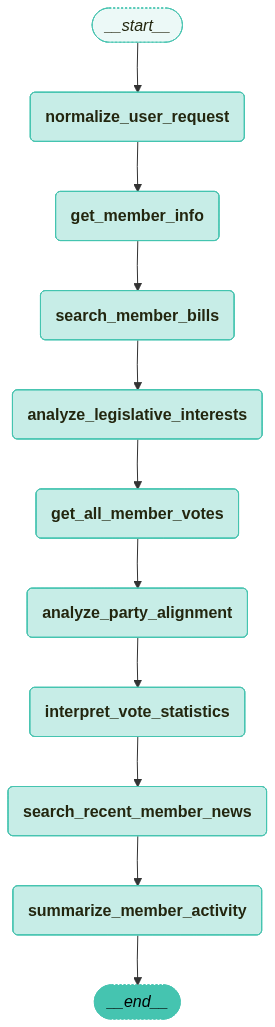

In [3]:
api_key = get_assembly_api_key()
client = AssemblyAPIClient(api_key=api_key)
member_activity_app = build_member_activity_graph(client)

if visualize_graph is not None:
    visualize_graph(member_activity_app)

In [4]:
# 사용자 직접 입력으로 워크플로우를 시작합니다.
# 중요: 이전 커널 상태로 실행되면 재임 대수 필터가 적용되지 않을 수 있으므로 버전을 확인합니다.
if globals().get("WORKFLOW_VERSION") != "member_activity_v11_readable_output":
    raise RuntimeError("커널에 이전 워크플로우 코드가 남아 있습니다. Kernel을 재시작한 뒤 위 셀부터 다시 실행하세요.")

# 노트북 중간 수정 후에도 최신 그래프를 쓰도록 마지막 셀에서 앱을 다시 빌드합니다.
if "client" not in globals():
    api_key = get_assembly_api_key()
    client = AssemblyAPIClient(api_key=api_key)
member_activity_app = build_member_activity_graph(client)

member_name = input("분석할 국회의원 이름을 입력하세요: ").strip()

initial_state = {
    "member_name": member_name,
    "assembly_terms": DEFAULT_TERMS,
    "recent_limit": 10,
    "max_bill_pages": DEFAULT_MAX_BILL_PAGES,
    "max_vote_pages": DEFAULT_MAX_VOTE_PAGES,
    "max_vote_bills_to_scan": DEFAULT_MAX_VOTE_BILLS_TO_SCAN,  # 상세 표결은 초기 대수 전체 조회
    "vote_fetch_workers": DEFAULT_VOTE_FETCH_WORKERS,
    "party_alignment_enabled": True,
    "party_alignment_vote_limit": DEFAULT_PARTY_ALIGNMENT_LIMIT,  # 정당 일치도는 최근 50건 기준
    "llm_insights_enabled": DEFAULT_LLM_INSIGHTS_ENABLED,
    "enable_cosponsor_scan": DEFAULT_ENABLE_COSPONSOR_SCAN,
    "max_cosponsor_scan_pages": DEFAULT_MAX_COSPONSOR_SCAN_PAGES,
    "show_progress": True,
}

print("[진행] LangGraph stream 실행 시작", flush=True)
result = None
for event in member_activity_app.stream(initial_state, stream_mode="updates"):
    for node_name, node_update in event.items():
        print(f"[stream] {node_name} 완료", flush=True)
        if node_update:
            result = {**(result or {}), **node_update}

if result is None:
    raise RuntimeError("워크플로우 결과가 비어 있습니다.")

print("[진행] 결과 표시 시작", flush=True)
display(Markdown(result["summary"]))

bill_columns = ["_ROLE", "AGE", "BILL_NO", "BILL_NAME", "PROPOSE_DT", "COMMITTEE", "PROC_RESULT", "DETAIL_LINK"]
bill_result_stat_columns = ["처리결과", "건수"]
bill_committee_stat_columns = ["소관위원회", "건수"]
vote_columns = ["_VOTE_RESULT", "AGE", "VOTE_DATE", "BILL_NO", "BILL_NAME", "LAW_TITLE", "CURR_COMMITTEE", "POLY_NM", "ORIG_NM", "BILL_URL"]
vote_summary_columns = ["AGE", "전체", "찬성", "반대", "기권", "불참"]
vote_fetch_stat_columns = ["AGE", "표결의안", "상세조회성공", "상세조회실패", "매칭표결", "캐시사용"]
party_alignment_summary_columns = ["AGE", "분석표결", "일치", "이탈", "불참", "판정제외", "일치율", "불참포함일치율"]
party_alignment_record_columns = ["분류", "AGE", "VOTE_DATE", "BILL_NO", "BILL_NAME", "정당", "의원표결", "정당다수입장", "정당내분포", "제외사유"]
party_alignment_fetch_stat_columns = ["AGE", "분석대상표결", "BILL_ID캐시적중", "API신규조회대상", "상세조회성공", "상세조회실패", "분석완료"]
member_columns = ["NAAS_NM", "PLPT_NM", "ELECD_NM", "ELECD_DIV_NM", "BLNG_CMIT_NM", "CMIT_NM", "RLCT_DIV_NM", "GTELT_ERACO", "_SERVED_TERMS"]
news_columns = ["title", "source", "published", "url"]


def display_recent_news(update: Dict[str, Any]) -> None:
    news_markdown = (
        "### 최근 의원 관련 이슈\n"
        f"- 검색 쿼리: `{update.get('recent_news_query', '')}`\n"
        f"- 검색 결과: 최근 뉴스 {len(update.get('recent_news_items', []))}건\n\n"
        + (update.get("recent_news_analysis") or "최근 의원 관련 이슈 분석 결과가 없습니다.")
        + "\n\n주의: 이 섹션은 웹 검색 결과 기반이며 열린국회정보 API의 공식 의정활동 데이터가 아닙니다."
    )
    display(Markdown(news_markdown))
    display_table("최근 의원 관련 기사 목록", update.get("recent_news_items", []), news_columns, limit=DEFAULT_RECENT_NEWS_LIMIT)


def display_vote_interpretation(update: Dict[str, Any], prefix: str = "") -> None:
    analysis = update.get("vote_interpretation_analysis")
    if analysis:
        display(Markdown(f"### {prefix}표결 통계 해석 시 주의할 점\n" + analysis))


def display_party_alignment(update: Dict[str, Any], prefix: str = "") -> None:
    display_table(f"{prefix}정당 다수 입장 일치 분석 요약", update.get("party_alignment_summary", []), party_alignment_summary_columns, limit=100)
    display_table(f"{prefix}정당 일치도 분석 상태", update.get("party_alignment_fetch_stats", []), party_alignment_fetch_stat_columns, limit=100)
    display_table(f"{prefix}정당 다수 입장 이탈 표결", update.get("party_alignment_dissent_votes", []), party_alignment_record_columns, limit=len(update.get("party_alignment_dissent_votes", [])))
    display_table(f"{prefix}정당 일치도 판정 제외 표결", update.get("party_alignment_excluded_votes", []), party_alignment_record_columns, limit=len(update.get("party_alignment_excluded_votes", [])))
    display_vote_interpretation(update, prefix=prefix)


if result.get("unsupported_bill_terms"):
    display(Markdown(
        "### 발의법안 API 제공 제한\n"
        f"{format_terms(result.get('unsupported_bill_terms', []))} 발의법안은 열린국회정보 API 제공 범위 밖입니다. "
        "이는 해당 의원의 발의법안이 없는 것이 아니라, API로 불러올 수 없는 대수라는 뜻입니다."
    ))

if result.get("bill_terms"):
    display(Markdown("### 발의법안 통계\n" + bill_result_summary_text(result.get("sponsored_bills", []))))
    display_table("발의법안 처리결과별 통계", result.get("bill_result_stats", []), bill_result_stat_columns, limit=100)
    display_table("발의법안 소관위원회별 통계", result.get("bill_committee_stats", []), bill_committee_stat_columns, limit=100)
    display_table("최근 대표발의 법안", result.get("representative_bills", []), bill_columns, limit=result.get("recent_limit", 10))
    display_table("최근 공동발의 법안", result.get("cosponsored_bills", []), bill_columns, limit=result.get("recent_limit", 10))
else:
    display(Markdown("### 발의법안\n선택한 대수는 모두 9대 이전이므로 열린국회정보 API 기준 발의법안을 불러올 수 없습니다."))

if result.get("unsupported_vote_terms"):
    display(Markdown(
        "### 본회의 표결정보 API 제공 제한\n"
        f"{format_terms(result.get('unsupported_vote_terms', []))} 표결정보는 열린국회정보 API 제공 범위 밖입니다. "
        "이는 해당 의원의 표결이 없는 것이 아니라, API로 불러올 수 없는 대수라는 뜻입니다."
    ))

if result.get("vote_terms"):
    display_table("대수별 표결 요약", result.get("vote_summary_by_term", []), vote_summary_columns, limit=100)
    display_table("표결 조회 상태", result.get("vote_fetch_stats", []), vote_fetch_stat_columns, limit=100)
    display_table("전체 찬성 표결", result.get("yes_votes", []), vote_columns, limit=len(result.get("yes_votes", [])))
    display_table("전체 반대 표결", result.get("no_votes", []), vote_columns, limit=len(result.get("no_votes", [])))
    display_table("전체 기권 표결", result.get("abstain_votes", []), vote_columns, limit=len(result.get("abstain_votes", [])))
    display_table("전체 불참 표결", result.get("absent_votes", []), vote_columns, limit=len(result.get("absent_votes", [])))
    display(Markdown(f"### 정당 다수 입장 일치 분석\n기본 분석은 대수별 최근 {result.get('party_alignment_vote_limit', DEFAULT_PARTY_ALIGNMENT_LIMIT)}건 기준입니다."))
    display_party_alignment(result)
else:
    display(Markdown("### 본회의 표결정보\n선택한 대수는 모두 20대 이전이므로 열린국회정보 API 기준 표결정보를 불러올 수 없습니다."))


display_recent_news(result)

# 2단계: 초기 결과 이후 사용자가 원하는 추가 작업을 하나 선택합니다.
additional_terms = result.get("additional_vote_terms", [])
can_select_more_terms = bool(additional_terms)
can_rerun_alignment = bool(result.get("vote_terms"))

choices = []
if can_select_more_terms:
    choices.append("1. 다른 재임 대수의 상세 표결 정보 조회")
if can_rerun_alignment:
    choices.append("2. 정당 다수 입장 일치 분석 범위 변경")

if choices:
    display(Markdown(
        "### 추가 작업 선택\n"
        + "\n".join(f"- {choice}" for choice in choices)
        + "\n\n원하는 작업 번호를 입력하세요. 건너뛰려면 Enter를 누르세요."
    ))
    selected_action = input("추가 작업 선택(1 또는 2): ").strip()

    if selected_action == "1" and can_select_more_terms:
        display(Markdown(
            "### 추가 표결 상세 조회 선택\n"
            f"초기 조회는 가장 최근 대수인 {format_terms(result.get('vote_terms', []))}만 수행했습니다. "
            f"추가 조회 가능 대수: {format_terms(additional_terms)}\n\n"
            "추가 조회할 대수를 쉼표 또는 공백으로 입력하세요. 예: `20` 또는 `20, 21`. 건너뛰려면 Enter를 누르세요."
        ))
        selected_text = input("추가 표결 상세 조회 대수 입력: ").strip()
        selected_terms = parse_term_selection(selected_text, additional_terms)
        invalid_numbers = [int(number) for number in re.findall(r"\d+", selected_text) if int(number) not in set(additional_terms)]
        if invalid_numbers:
            display(Markdown(f"선택할 수 없는 대수는 제외했습니다: {format_terms(invalid_numbers)}"))
        if selected_terms:
            display(Markdown(f"### 추가 표결 상세 조회 실행: {format_terms(selected_terms)}"))
            vote_only_state = {
                **result,
                "vote_terms": selected_terms,
                "errors": [],
                "show_progress": True,
            }
            vote_update = make_fetch_votes_node(client)(vote_only_state)
            display_table("추가 대수별 표결 요약", vote_update.get("vote_summary_by_term", []), vote_summary_columns, limit=100)
            display_table("추가 표결 조회 상태", vote_update.get("vote_fetch_stats", []), vote_fetch_stat_columns, limit=100)
            display_table("추가 찬성 표결", vote_update.get("yes_votes", []), vote_columns, limit=len(vote_update.get("yes_votes", [])))
            display_table("추가 반대 표결", vote_update.get("no_votes", []), vote_columns, limit=len(vote_update.get("no_votes", [])))
            display_table("추가 기권 표결", vote_update.get("abstain_votes", []), vote_columns, limit=len(vote_update.get("abstain_votes", [])))
            display_table("추가 불참 표결", vote_update.get("absent_votes", []), vote_columns, limit=len(vote_update.get("absent_votes", [])))
            if vote_update.get("errors"):
                display(Markdown("### 추가 조회 중 확인할 점\n" + "\n".join(f"- {error}" for error in vote_update["errors"])))
        else:
            display(Markdown("추가 표결 상세 조회를 건너뛰었습니다."))

    elif selected_action == "2" and can_rerun_alignment:
        display(Markdown(
            "### 정당 다수 입장 일치 분석 범위 변경\n"
            f"현재 분석 대수: {format_terms(result.get('vote_terms', []))}\n\n"
            "최근 몇 건 기준으로 다시 분석할지 입력하세요. 예: `100`. 전체 표결을 분석하려면 `0`을 입력하세요."
        ))
        limit_text = input("정당 일치도 분석 범위 입력: ").strip()
        selected_limit = parse_nonnegative_int(limit_text, DEFAULT_PARTY_ALIGNMENT_LIMIT)
        scope_label = "전체" if selected_limit == 0 else f"최근 {selected_limit}건"
        display(Markdown(f"### 정당 다수 입장 일치 분석 재실행: 대수별 {scope_label}"))
        alignment_state = {
            **result,
            "party_alignment_vote_limit": selected_limit,
            "errors": [],
            "show_progress": True,
        }
        alignment_update = make_analyze_party_alignment_node(client)(alignment_state)
        interpretation_update = analyze_vote_interpretation_node({**alignment_state, **alignment_update})
        alignment_update = {**alignment_update, **interpretation_update}
        display_party_alignment(alignment_update, prefix="재분석 ")
        if alignment_update.get("errors"):
            display(Markdown("### 재분석 중 확인할 점\n" + "\n".join(f"- {error}" for error in alignment_update["errors"])))

    elif selected_action:
        display(Markdown("선택할 수 없는 작업 번호입니다. 추가 작업을 실행하지 않았습니다."))
    else:
        display(Markdown("추가 작업을 건너뛰었습니다."))
else:
    if result.get("all_vote_terms"):
        display(Markdown("### 추가 작업\n이 의원은 표결 API가 지원하는 재임 대수가 초기 조회 대수뿐입니다. 정당 일치도 재분석은 초기 표결 대수가 있을 때만 가능합니다."))
    else:
        display(Markdown("### 추가 작업\n이 의원의 재임 대수 중 열린국회정보 표결 API가 지원하는 대수가 없어 추가 작업을 진행하지 않습니다."))

[진행] LangGraph stream 실행 시작
[진행] 입력 정리 완료: 정청래, 요청 대수 22대, 21대, 20대, 19대, 18대, 17대, 16대, 15대, 14대, 13대, 12대, 11대, 10대, 9대, 8대, 7대, 6대, 5대, 4대, 3대, 2대, 1대
[stream] normalize_user_request 완료
[진행] 의원 기본정보 조회 시작
[진행] 의원 기본정보 조회 완료: 1건, 재임 대수 22대, 21대, 19대, 17대
[stream] get_member_info 완료
[진행] 발의법안 조회 시작: 22대, 21대, 19대, 17대
[진행] 22대 공동발의 보강 스캔: 최대 5페이지
[진행] 22대 발의법안 조회 완료: 54건 추가
[진행] 21대 공동발의 보강 스캔: 최대 5페이지
[진행] 21대 발의법안 조회 완료: 354건 추가
[진행] 19대 공동발의 보강 스캔: 최대 5페이지
[진행] 19대 발의법안 조회 완료: 356건 추가
[진행] 17대 공동발의 보강 스캔: 최대 5페이지
[진행] 17대 발의법안 조회 완료: 74건 추가
[진행] 발의법안 정리 완료: 전체 445건, 대표 393건, 공동 52건
[stream] search_member_bills 완료
[진행] 입법 관심 분야 분석 시작


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[진행] 입법 관심 분야 분석 완료: llm
[stream] analyze_legislative_interests 완료
[진행] 표결정보 조회 시작: 22대, 대수별 전체, 병렬 8개, 캐시 TTL 24시간
[진행] 22대 표결 의안 후보 1595건 확보
[진행] 22대 표결 상세 조회 진행: 25/1595 (성공 25, 실패 0)
[진행] 22대 표결 상세 조회 진행: 50/1595 (성공 50, 실패 0)
[진행] 22대 표결 상세 조회 진행: 75/1595 (성공 75, 실패 0)
[진행] 22대 표결 상세 조회 진행: 100/1595 (성공 100, 실패 0)
[진행] 22대 표결 상세 조회 진행: 125/1595 (성공 125, 실패 0)
[진행] 22대 표결 상세 조회 진행: 150/1595 (성공 150, 실패 0)
[진행] 22대 표결 상세 조회 진행: 175/1595 (성공 175, 실패 0)
[진행] 22대 표결 상세 조회 진행: 200/1595 (성공 200, 실패 0)
[진행] 22대 표결 상세 조회 진행: 225/1595 (성공 225, 실패 0)
[진행] 22대 표결 상세 조회 진행: 250/1595 (성공 250, 실패 0)
[진행] 22대 표결 상세 조회 진행: 275/1595 (성공 275, 실패 0)
[진행] 22대 표결 상세 조회 진행: 300/1595 (성공 300, 실패 0)
[진행] 22대 표결 상세 조회 진행: 325/1595 (성공 325, 실패 0)
[진행] 22대 표결 상세 조회 진행: 350/1595 (성공 350, 실패 0)
[진행] 22대 표결 상세 조회 진행: 375/1595 (성공 375, 실패 0)
[진행] 22대 표결 상세 조회 진행: 400/1595 (성공 400, 실패 0)
[진행] 22대 표결 상세 조회 진행: 425/1595 (성공 425, 실패 0)
[진행] 22대 표결 상세 조회 진행: 450/1595 (성공 450, 실패 0)
[진행] 22대 표결 상세 조회 진행: 475/1595 (성공 

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[진행] 표결 통계 해석 메모 생성 완료
[stream] interpret_vote_statistics 완료
[진행] 최근 의원 관련 뉴스 검색 시작


...

### 최근 의원 관련 이슈
- 검색 쿼리: `정청래 국회의원 열린우리당/민주통합당/더불어민주당/더불어민주당`
- 검색 결과: 최근 뉴스 0건

최근 뉴스 검색에 실패해 의원 관련 이슈를 요약하지 못했습니다.

주의: 이 섹션은 웹 검색 결과 기반이며 열린국회정보 API의 공식 의정활동 데이터가 아닙니다.

### 최근 의원 관련 기사 목록

조회된 데이터가 없습니다.

### 추가 작업 선택
- 1. 다른 재임 대수의 상세 표결 정보 조회
- 2. 정당 다수 입장 일치 분석 범위 변경

원하는 작업 번호를 입력하세요. 건너뛰려면 Enter를 누르세요.

추가 작업을 건너뛰었습니다.

## 코드 설명

이 노트북은 열린국회정보 API를 LangGraph 워크플로우로 묶은 의원 활동 추적 구현입니다.

### 2차 표결 조회 방식

- 사용자가 의원명을 입력하면 먼저 `ALLNAMEMBER`에서 의원 재임 대수를 확인합니다.
- 초기 의원 활동 조회에서는 표결 API가 지원하는 재임 대수 중 **가장 최근 대수 1개만** 상세 표결 전체를 조회합니다.
  - 예: 이준석 의원은 22대만 재임했으므로 22대 전체 표결을 조회합니다.
  - 예: 추미애 의원은 여러 대수를 지냈더라도 초기 상세 표결 조회는 가장 최근 지원 대수인 22대 전체 표결만 조회합니다.
- 정당 다수 입장 일치 분석은 초기 실행에서 **최근 50건**만 분석합니다.
- 초기 결과 출력 후 사용자는 두 가지 추가 작업 중 하나를 선택할 수 있습니다.
  - `1`: 다른 재임 대수의 상세 표결 정보 조회
  - `2`: 정당 다수 입장 일치 분석 범위를 최근 N건 또는 전체로 바꿔 재분석
- 표결 API 지원 범위 밖인 재임 대수는 선택 후보가 아니라 안내 메시지로 분리합니다.
- 발의법안은 목록뿐 아니라 전체 건수, 처리결과별 통계, 소관위원회별 통계를 함께 표시합니다.
- 발의법안 조회 직후 입법 관심 분야 분석을 생성해 최초 의원 활동 조회 결과에 함께 표시합니다.
- 마지막에는 `{의원이름} 국회의원 {정당명}` 쿼리로 최근 뉴스 10건을 검색하고, Gemini로 최근 의원 관련 이슈를 별도 섹션에 요약합니다.

### 정당 다수 입장 일치 분석

- API에 공식 당론 필드가 없으므로, 이 분석의 기준은 `공식 당론`이 아니라 **해당 표결에서 같은 정당 의원 다수가 선택한 표결값**입니다.
- `BILL_ID`별 전체 의원 표결을 가져와 정당별 `찬성/반대/기권/불참` 분포를 계산합니다.
- 전체 의원 표결 조회는 API의 페이지 제한을 고려해 `pSize=100`, `max_pages=5`로 가져오며, 예전 불완전 캐시와 충돌하지 않도록 `bill_votes_full_v2` 캐시를 사용합니다.
- 전체 의원 표결 row에서 해당 의원명을 직접 찾지 못하면, 직전 표결 상세 조회에서 확보한 해당 의원의 `BILL_ID`별 표결 row를 fallback으로 사용합니다.
- 그래도 해당 `BILL_ID`의 의원 row가 없고 의원의 정당을 추정할 수 있으면, MCP 예시처럼 해당 표결을 `불참(추정)`으로 분류하고 정당 다수 입장 계산을 계속합니다.
- 불참은 정당 다수 입장 계산에서 제외하고, `찬성/반대/기권` 중 최다값을 정당 다수 입장으로 봅니다.
- 의원 표결이 정당 다수 입장과 같으면 `일치`, 다르면 `이탈`, 의원 표결이 불참이면 `불참`으로 분류합니다.
- 무소속, 정당 내 표결자 1명, 찬성/반대/기권 동률 등은 `판정 제외`로 분리합니다.

### 입법 관심 분야 분석

- 입력 context는 발의 법안 전체 수, 대표발의/공동발의 수, 처리결과별 통계, 소관위원회별 통계, 최근 대표발의/공동발의 법안 목록입니다.
- `GOOGLE_API_KEY` 또는 `GEMINI_API_KEY`와 `langchain_google_genai`가 있으면 LangChain `ChatGoogleGenerativeAI`로 LLM 분석을 생성합니다.
- 입법 관심 분야 분석 모델은 `gemini-2.5-flash-lite`로 고정되어 있으며, 환경변수로 모델명을 바꾸지 않습니다.
- Gemini 키나 패키지가 없으면 워크플로우가 중단되지 않도록 같은 context를 규칙 기반 요약으로 대체합니다.
- 출력은 주요 관심 의제, 근거 위원회/법안, 해석상 주의점을 Markdown으로 제공합니다.

### 최근 의원 관련 이슈 분석

- 검색 쿼리는 동명이인 문제를 줄이기 위해 `{의원이름} 국회의원 {정당명}` 형식으로 만듭니다.
- Google News RSS에서 최근 기사 10건만 가져오며, 검색 결과와 요약은 각각 6시간 캐시합니다.
- Gemini `gemini-2.5-flash-lite`가 기사 제목, 언론사, 날짜, 요약문을 바탕으로 최근 이슈 3~5개를 요약합니다.
- 이 섹션은 웹 검색 기반 공개 맥락이며 열린국회정보 API의 공식 의정활동 데이터와 분리해서 해석해야 합니다.

### 사용 API

- `ALLNAMEMBER`: 의원 기본정보와 재임 대수 확인
- `nzmimeepazxkubdpn`: 국회의원 발의법률안 조회
- `ncocpgfiaoituanbr`: 대수별 표결 의안 목록 조회
- `nojepdqqaweusdfbi`: `BILL_ID + 의원명/의원코드` 기준 의원별 표결 조회, `BILL_ID` 기준 전체 의원 표결 조회

### 그래프 노드

1. `normalize_user_request`: 입력 의원명, 요청 대수, 조회 옵션을 정리합니다.
2. `get_member_info`: 의원 프로필과 `GTELT_ERACO` 기반 재임 대수를 확인합니다.
3. `search_member_bills`: 재임 대수 중 API 지원 범위에서 대표발의/공동발의 법안을 조회합니다.
4. `analyze_legislative_interests`: 발의법안 통계와 최근 법안 목록을 바탕으로 입법 관심 분야 분석을 생성합니다.
5. `get_all_member_votes`: 초기 조회 대상 대수 1개에 대해서 상세 표결 전체를 병렬 조회합니다.
6. `analyze_party_alignment`: 같은 정당의 다수 표결값과 의원 표결을 비교해 일치/이탈/불참/판정 제외를 계산합니다.
7. `interpret_vote_statistics`: 표결 범위, 날짜 쏠림, 불참 비중을 바탕으로 통계 해석 시 주의할 점을 생성합니다.
8. `search_recent_member_news`: 최근 뉴스 10건을 검색하고 Gemini로 최근 의원 관련 이슈를 요약합니다.
9. `summarize_member_activity`: 의원 프로필, 발의법안 통계, 입법 관심 분야 분석, 대수별 표결 요약, 정당 일치도, 조회 성공/실패 상태를 마크다운으로 정리합니다.

### 성능과 안정성

- 표결 의안 목록, `BILL_ID`별 의원 표결 결과, `BILL_ID`별 전체 의원 표결 결과, 최근 뉴스 검색 결과를 파일 캐시에 저장합니다.
- 캐시 TTL은 `CACHE_TTL_HOURS = 24`입니다. 캐시 파일이 24시간보다 오래되면 API를 다시 호출합니다.
- 표결 상세 조회와 정당 일치도 분석은 `ThreadPoolExecutor`로 병렬 처리합니다.
- 표결 일부가 실패해도 워크플로우는 계속 진행하며, 조회 상태 표에 성공/실패 건수를 표시합니다.
- 표결정보는 누락 행을 불참으로 추정하지 않습니다. API가 명시적으로 반환한 `RESULT_VOTE_MOD` 값만 찬성, 반대, 기권, 불참으로 분류합니다.


사용자가 의원 이름 작성 -> 표결 조회는 가장 최근 대수 -> 이후에 이 의원은 이 대수 말고도 ~ 대수에도 재임했습니다.  추가로 표결정보 보시겠습니가? 로 선택하게 만들기 -> 그리고 그 결과 동일하게 보여주고 단축키에 합쳐서 보기 즉, 처음에 했던 가장 최근 대수랑 사용자가 선택 또는 복수선택한 표결정보랑 함께 같이 보기(캐시 남은거 불러오면 되니까. 이전에 한 정보들의 경우 다시 하지 않고!) ---> 이 내용 내일 수정하자 

메모: 최근 뉴스 rss로 불러올 때 10건 요약만 보고 해야하나 아니면 그 중 몇건만 선택해서 해야하나..?